# NB01b — AOI.geojson Construction (Overture + UNOSAT + Boundaries)

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.



| Field | Value |
|-------|-------|
| **Notebook** | `01b_overture_unosat_v7.ipynb` |
| **Version** | v7 |
| **Pipeline position** | Foundation notebook. Creates AOI.geojson — the MASTER file per city. |
| **Last validated** | 2026-04-XX |

## Narrative

This notebook constructs `AOI.geojson` — the single source of truth per city for
the entire BDA pipeline. Every downstream notebook (NB02-NB11) reads from AOI.geojson.

After NB01a established that OSM building footprints are unsuitable for damage assessment,
this notebook uses **Overture Maps** building footprints (Microsoft+Google+OSM conflation)
as the building inventory. Overture provides more complete and geometrically consistent
footprints than OSM alone.

**UNOSAT damage labels** from the Dietrich et al. (2025) compilation are spatially joined
onto Overture buildings using a two-stage method: (1) point-in-polygon spatial join,
(2) nearest-neighbor matching within 15m for remaining unmatched points.

Cell 19 merges three geometry types into one GeoJSON per city:
- `aoi_bbox`: 64-aligned rectangular bounding box (50m buffer, 10m grid)
- `city_polygon`: administrative boundary from COD-AB
- `building`: Overture footprints with damage labels attached

The result is a self-contained AOI.geojson that all downstream notebooks consume.

## Research Questions Addressed
- **RQ-data:** Can Overture Maps provide sufficient building coverage for BDA at 10m resolution?
- **RQ-data:** What fraction of UNOSAT damage points match to Overture buildings?
- **RQ-data:** What is the spatial completeness of Dietrich UNOSAT labels within each city extent?

## Scientific Rationale
NB01a showed OSM temporal comparison is unsuitable for damage assessment. Overture Maps
aggregates building footprints from Microsoft ML, Google Open Buildings, and OSM into
a single conflated dataset with higher completeness than any individual source.

Dietrich et al. (2025) used Overture footprints with UNOSAT labels for their RF baseline.
We replicate this data construction but extend to all 50 cities (not just their 6) and
preserve the full pipeline in a single portable GeoJSON per city.

The 64-pixel-aligned bounding box (Cell 8 NUCLEUS) ensures all raster products from
NB03/NB05 share exact pixel grids without resampling artifacts. The 50m buffer prevents
edge effects in spatial feature extraction.

UNOSAT label limitations must be acknowledged: labels are incomplete (Aimaiti et al. 2022),
buildings without UNOSAT points are assumed undamaged (damage_binary=-1), and only 6 of
50 cities have labels. This is the Achilles heel of the entire pipeline.

## Inputs

| Data | Source | Format |
|------|--------|--------|
| `boundary.geojson` per city | NB01a Cell 8 | GeoJSON |
| `bda_city_boundaries.geojson` | NB01a Cell 8 | GeoJSON |
| `cities_config.json` | Manual | JSON |
| Overture Maps buildings | Downloaded via `overturemaps` Python package | GeoJSON |
| `unosat_labels.geojson` (Dietrich) | NB01a Cell 13/15 | GeoJSON (18,686 points) |
| `unosat_aois.geojson` (Dietrich AOI polygons) | Dietrich supplementary | GeoJSON |

## Outputs

| Artifact | Path | Used by |
|----------|------|---------|
| `AOI.geojson` per city | `CITIES_DIR/{city}/AOI.geojson` | **ALL downstream** (NB02-NB11) |
| `{city}_buildings_overture.geojson` | `OVERTURE_DIR/` | NB01b Cell 18B (intermediate) |
| `{city}_buildings_overture_with_damage.geojson` | `CITIES_DIR/{city}/` | NB01b Cell 19 (intermediate) |
| `unosat_damage.geojson` per city | `UNOSAT_CITIES_DIR/{city}/` | NB01b Cell 18B |
| `dietrich_unosat_aoi.geojson` per city | `UNOSAT_CITIES_DIR/{city}/` | NB01b Cell 18A |
| `bda.sqlite` (cities table) | `CATALOG_DB` | NB05, NB09 |

## Prerequisites
- NB01a Cell 8 must have run (boundary.geojson per city)
- NB01a Cell 15/17 must have run (UNOSAT per-city extraction)
- Internet access for Overture Maps download (Cell 12B)
- `pip install overturemaps`

## Key Methodological Choices

| Choice | Justification | Reference |
|--------|---------------|-----------|
| Overture Maps over OSM | Higher completeness, ML-conflated | NB01a Cell 12 negative result |
| 64-pixel-aligned bbox | Ensures raster grid alignment across all products | NB05 patch generation |
| 50m buffer | Prevents edge effects in zonal statistics | Standard practice |
| 10m target resolution | Matches Sentinel-1/2 native resolution | Dietrich 2025 |
| 15m nearest-neighbor threshold | Balances match rate vs false assignment | Cell 18B2 analysis |
| Binary labels (severe+destroyed=1) | Match Dietrich protocol | Dietrich 2025 |
| damage_binary=-1 for unlabeled | Explicit unknown vs assumed undamaged | Thesis limitation |
| Single AOI.geojson per city | Portable, self-contained, no side-loading | Architecture principle |

## Known Limitations
- UNOSAT labels incomplete — only 6 of 50 cities have labels
- Buildings without UNOSAT point assumed undamaged (damage_binary=-1)
- Overture may miss fully destroyed buildings (no footprint = no feature)
- Dietrich AOI extent may not cover full city bbox (Cell 18A diagnostic)
- AOI.geojson files written without indentation (up to 131MB for Mariupol)

## Cell Structure

| Cell | ID | What | Status |
|------|----|------|--------|
| 0 | — | Documentation (this cell) | — |
| 1 | Cell 3 | Config (CLIP_MODE, TARGET_RES, BUFFER_M) | Config |
| 2 | Cell 4 | Load global_setup | Config |
| 3-4 | Cell 5 | Ukraine boundaries | Config |
| 5-6 | Cell 6 | ADM0-ADM4 layers | Config |
| 7-8 | Cell 8 | City boundaries + battle dates (**NUCLEUS**) | **Core** |
| 9-10 | Cell 12B | Download Overture buildings per city | **Core** |
| 11-12 | Cell 12B2 | Clip Overture to city extent | **Core** |
| 13-14 | Cell 15 | Extract UNOSAT damage per city | **Core** |
| 15-16 | Cell 15B | Save Dietrich AOI boundaries per city | **Core** |
| 17-18 | Cell 16 | UNOSAT damage classification + EMS-98 mapping | **Core** |
| 19-20 | Cell 17 | Compile UNOSAT with EMS-98 mapping | **Core** |
| 21-22 | Cell 18A | UNOSAT extent vs city bbox diagnostic | Diagnostic |
| 23-24 | Cell 18B | Overlay UNOSAT onto Overture buildings | **Core** |
| 25-26 | Cell 18B2 | Unmatched UNOSAT point distance analysis | Diagnostic |
| 27-28 | Cell 19 | **MERGE ALL INTO AOI.geojson** (**NUCLEUS**) | **Core** |
| 29-30 | Cell 20 | Verify AOI.geojson integrity | QA |
| 31-32 | Cell SQLITE | Register city metadata in bda.sqlite | **Core** |

## Thesis Mapping

| Thesis Section | Cells | Content |
|----------------|-------|---------|
| 3.2 Data Sources — Building Footprints | 12B, 12B2 | Overture Maps download, coverage |
| 3.2 Data Sources — Damage Labels | 15, 15B, 16, 17 | UNOSAT extraction, EMS-98 mapping |
| 3.2 Data Sources — Label Limitations | 18A, 18B, 18B2 | Spatial coverage, match rates, unmatched analysis |
| 3.3 Preprocessing — AOI Construction | 8, 19, 20 | Bbox alignment, merge, verification |
| 3.3 Preprocessing — Data Catalog | SQLITE | bda.sqlite registration |

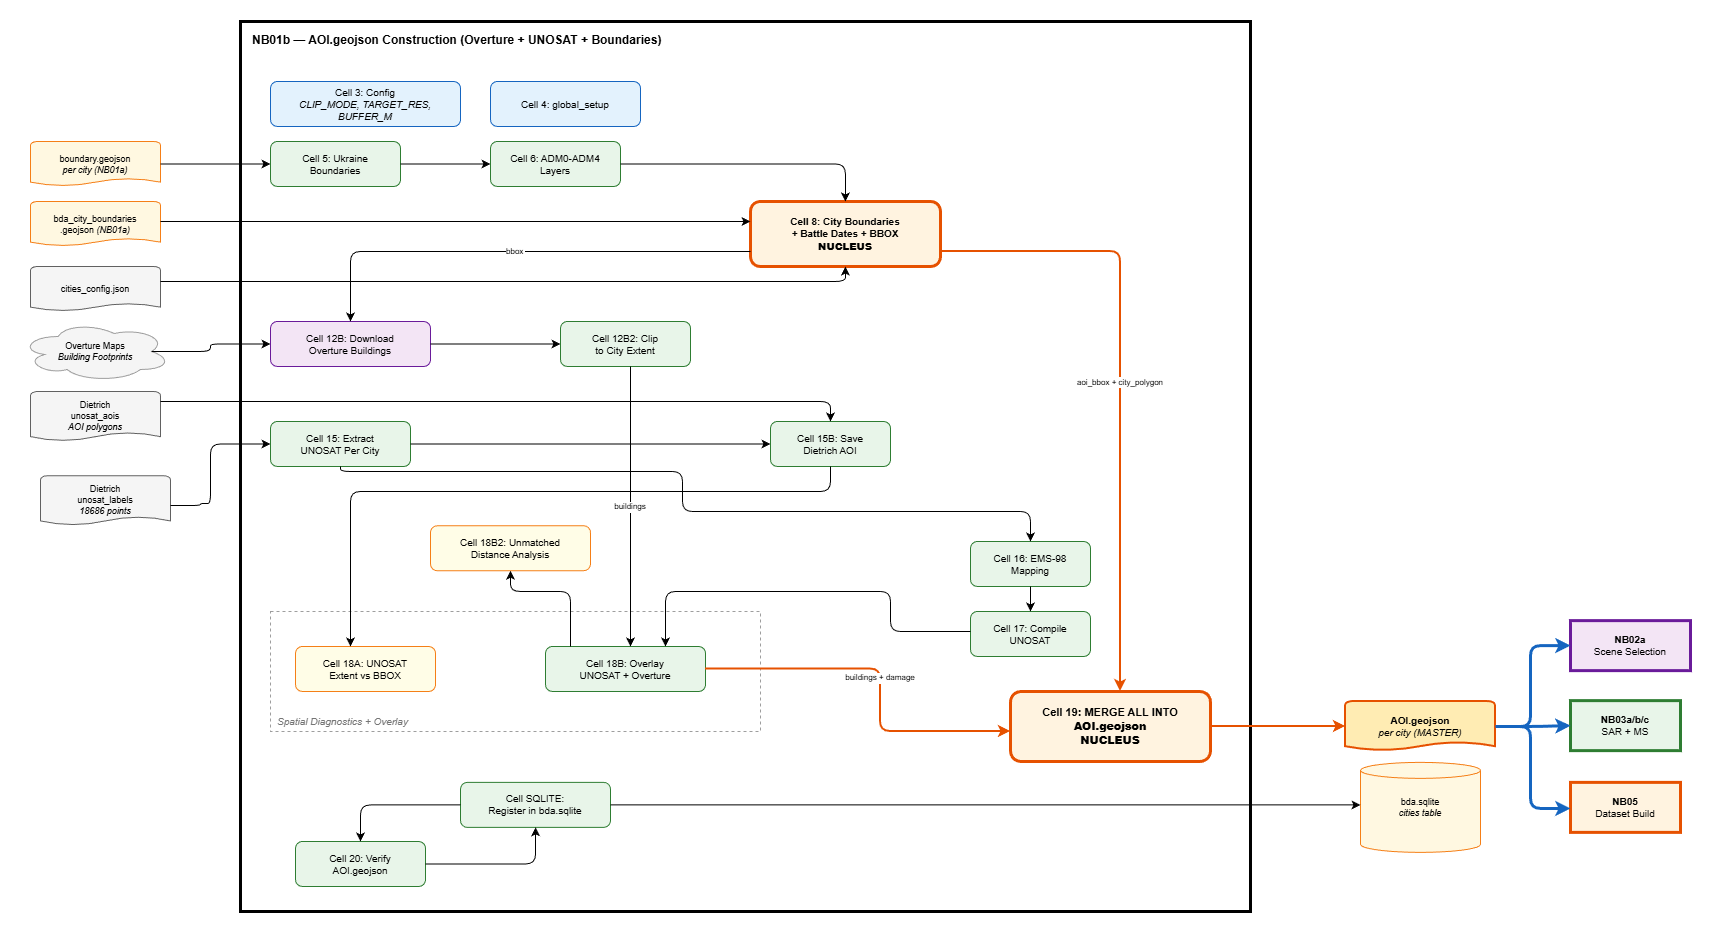

# CELL 4: COMPLETE ENVIRONMENT SETUP (BDA + SNAP12) - LOCAL WSL VERSION


In [1]:
# @title CELL 3: NB01b CONFIG
# ---- nucleus cell 8 (bbox alignment + city creation) ----
CLIP_MODE = "bbox"                 # "bbox" or "polygon"
TARGET_RES = 10.0
PREFERRED_DIVISOR = 256
BUFFER_M = 50.0
# ---- cell 16 (UNOSAT analysis) ----
PLOT_ALL_CITIES = True
# ---- cell 17 (UNOSAT compile) ----
VERIFY_UKRAINE_COORDS = True
DROP_SPARSE_COLUMNS = True
# ---- cell 18B/18B2 (damage overlay) ----
MAX_DISTANCE_METERS = 10
CREATE_DETAILED_MAPS = True

In [2]:
# @title CELL 4: LOAD GLOBAL SETUP
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())

/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


BDA GLOBAL SETUP
Started: 2026-07-12 15:54:45
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------
  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: False
  CITIES_TO_PROCESS: 20 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:564: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     954.5/7452.0 GB (6497.5 GB free)
  GDrive (F:)     1409.4/3726.0 GB (2316.6 GB free)
  Local data      11563.9/14901.9 GB (3337.9 GB free)
  Data stack      1409.4/3726.0 GB (2316.6 GB free)
  WSL ext4        75.2/1006.9 GB (880.5 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 20, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

# CELL 5: LOAD & VISUALIZE UKRAINE BOUNDARIES

LOADING UKRAINE BOUNDARIES

Admin boundary shapefiles: 7
  ukr_admbnda_adm0_sspe_20240416: 1 features, CRS=EPSG:4326
  ukr_admbnda_adm1_sspe_20240416: 27 features, CRS=EPSG:4326
  ukr_admbnda_adm2_sspe_20240416: 139 features, CRS=EPSG:4326
  ukr_admbnda_adm3_sspe_20240416: 1769 features, CRS=EPSG:4326
  ukr_admbnda_adm4_sspe_20240416: 29707 features, CRS=EPSG:4326
  ukr_admbndl_adm0123_sspe_itos_20240416: 5833 features, CRS=EPSG:4326
  ukr_admbndp_adm0123_sspe_itos_20240416: 1769 features, CRS=EPSG:4326

City boundaries: 50 cities
  Loaded: 50 city boundaries
    Avdiivka                 : 28.2 km2
    Bakhmut                  : 40.2 km2
    Balakliia                : 21.5 km2
    Borodyanka               : 513.1 km2
    Bucha                    : 26.4 km2
    ... and 45 more

VISUALIZATION

Saved: /content/drive_f/masterthesis/data/outputs/cell_05_ukraine_boundaries/boundaries_overview.png


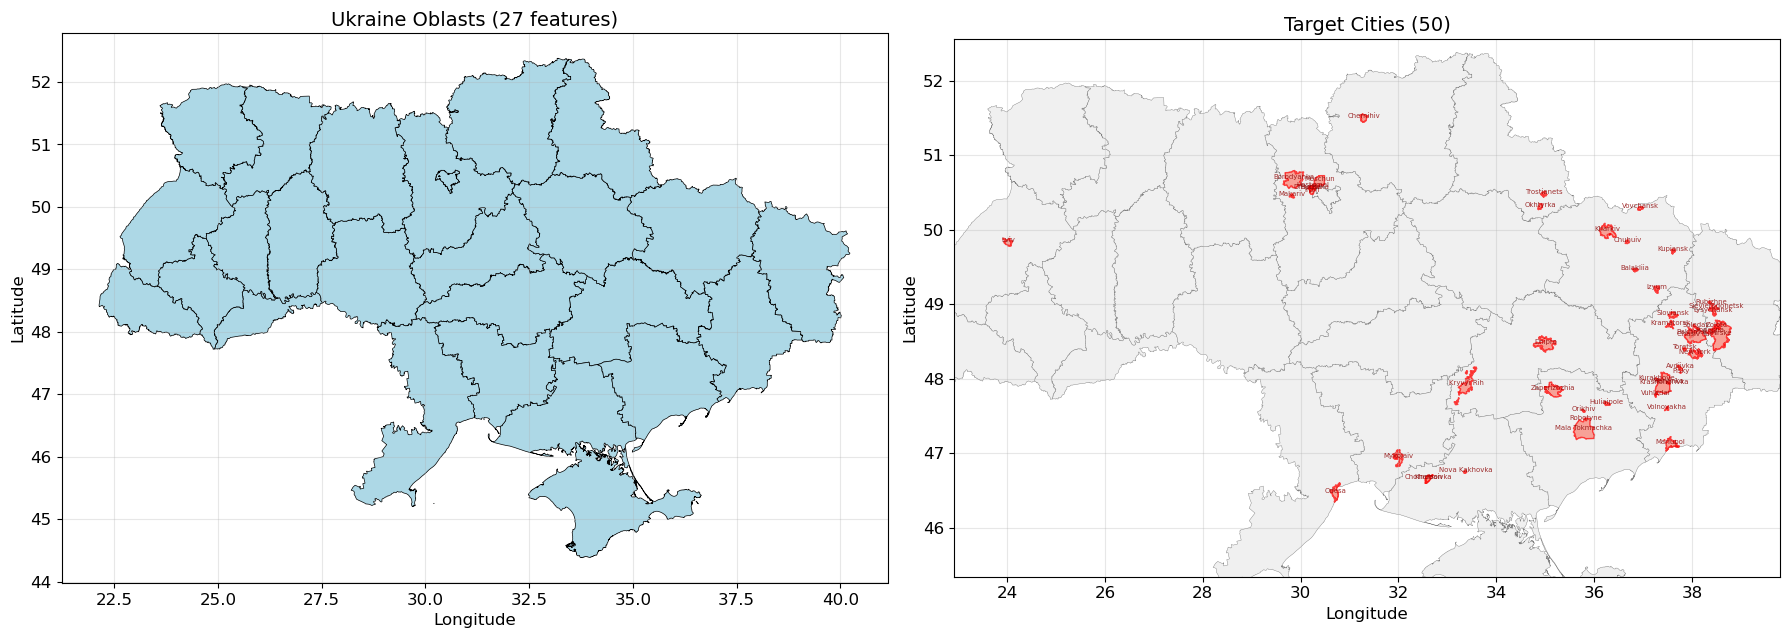


BOUNDARIES LOADED (12.0s)
  Admin layers: 7
  City boundaries: 50


In [3]:
# @title CELL 5: LOAD & VISUALIZE UKRAINE BOUNDARIES
# =============================================================================
# Loads admin boundary shapefiles, city boundaries, creates overview map.
# Requires: Cell 4 + Cell 4A (paths)
# =============================================================================

CELL_ID = "cell_05_ukraine_boundaries"
FORCE_RERUN = True

import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import json
from datetime import datetime

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 5 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    boundaries = previous_log.get('boundaries', {})
    print(f"  {len(boundaries)} boundary layers available")
else:
    start_time = datetime.now()

    print("=" * 70)
    print("LOADING UKRAINE BOUNDARIES")
    print("=" * 70)

    # ========================================================================
    # ADMIN BOUNDARIES (shapefiles)
    # ========================================================================

    boundaries = {}
    admin_levels = {}

    boundary_path = Path(UKR_BOUNDARIES)
    if boundary_path.exists():
        boundary_files = list(boundary_path.glob("*.shp"))
        print(f"\nAdmin boundary shapefiles: {len(boundary_files)}")

        for shp_file in boundary_files:
            try:
                gdf = gpd.read_file(shp_file)
                layer_name = shp_file.stem
                boundaries[layer_name] = gdf
                print(f"  {layer_name}: {len(gdf)} features, CRS={gdf.crs}")

                if 'adm0' in layer_name.lower() or 'country' in layer_name.lower():
                    admin_levels['country'] = gdf
                elif 'adm1' in layer_name.lower() or 'oblast' in layer_name.lower():
                    admin_levels['oblast'] = gdf
                elif 'adm2' in layer_name.lower() or 'raion' in layer_name.lower():
                    admin_levels['raion'] = gdf
            except Exception as e:
                print(f"  ERROR loading {shp_file.name}: {e}")
    else:
        print(f"  Admin boundaries not found: {boundary_path}")

    # ========================================================================
    # CITY BOUNDARIES (geojson per city)
    # ========================================================================

    cities_path = Path(CITIES_DIR)
    city_boundaries = {}

    if cities_path.exists():
        city_dirs = sorted([d for d in cities_path.iterdir() if d.is_dir()])
        print(f"\nCity boundaries: {len(city_dirs)} cities")

        for city_dir in city_dirs:
            geojson_file = city_dir / 'boundary.geojson'
            if geojson_file.exists():
                try:
                    gdf = gpd.read_file(geojson_file)
                    city_boundaries[city_dir.name] = gdf
                except Exception as e:
                    print(f"  ERROR loading {city_dir.name}: {e}")

        print(f"  Loaded: {len(city_boundaries)} city boundaries")

        if city_boundaries:
            # show sample
            for name, gdf in list(city_boundaries.items())[:5]:
                area_km2 = gdf.to_crs(epsg=32636).geometry.area.sum() / 1e6
                print(f"    {name:25s}: {area_km2:.1f} km2")
            if len(city_boundaries) > 5:
                print(f"    ... and {len(city_boundaries) - 5} more")
    else:
        print(f"  Cities dir not found: {cities_path}")

    # ========================================================================
    # VISUALIZATION
    # ========================================================================

    print(f"\n{'='*70}")
    print("VISUALIZATION")
    print(f"{'='*70}")

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Plot 1: Admin boundaries
    ax1 = axes[0]
    if 'oblast' in admin_levels:
        admin_levels['oblast'].plot(ax=ax1, edgecolor='black', facecolor='lightblue', linewidth=0.5)
        ax1.set_title(f"Ukraine Oblasts ({len(admin_levels['oblast'])} features)")
    elif 'country' in admin_levels:
        admin_levels['country'].plot(ax=ax1, edgecolor='black', facecolor='lightblue', linewidth=1)
        ax1.set_title("Ukraine Country Boundary")
    elif boundaries:
        first_layer = list(boundaries.values())[0]
        first_layer.plot(ax=ax1, edgecolor='black', facecolor='lightblue', linewidth=0.5)
        ax1.set_title(f"Boundaries ({len(first_layer)} features)")
    else:
        ax1.text(0.5, 0.5, 'No admin boundaries loaded', ha='center', va='center', transform=ax1.transAxes)
        ax1.set_title("Admin Boundaries (missing)")

    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')
    ax1.grid(True, alpha=0.3)

    # Plot 2: City boundaries on top of admin
    ax2 = axes[1]
    if 'oblast' in admin_levels:
        admin_levels['oblast'].plot(ax=ax2, edgecolor='gray', facecolor='#f0f0f0', linewidth=0.3)
    elif 'country' in admin_levels:
        admin_levels['country'].plot(ax=ax2, edgecolor='gray', facecolor='#f0f0f0', linewidth=0.5)

    if city_boundaries:
        all_cities_gdf = gpd.GeoDataFrame(
            pd.concat([gdf.assign(city=name) for name, gdf in city_boundaries.items()], ignore_index=True)
        )
        all_cities_gdf.plot(ax=ax2, edgecolor='red', facecolor='salmon', linewidth=1, alpha=0.7)

        # label cities
        for name, gdf in city_boundaries.items():
            centroid = gdf.geometry.centroid.iloc[0]
            ax2.annotate(name, xy=(centroid.x, centroid.y), fontsize=5, ha='center',
                        alpha=0.8, color='darkred')

    ax2.set_title(f"Target Cities ({len(city_boundaries)})")
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')
    ax2.grid(True, alpha=0.3)

    # zoom to cities area if available
    if city_boundaries:
        all_bounds = all_cities_gdf.total_bounds
        pad = 1.0
        ax2.set_xlim(all_bounds[0] - pad, all_bounds[2] + pad)
        ax2.set_ylim(all_bounds[1] - pad, all_bounds[3] + pad)

    plt.tight_layout()

    fig_path = Path(OUTPUTS_DIR) / CELL_ID
    fig_path.mkdir(exist_ok=True)
    plt.savefig(fig_path / "boundaries_overview.png", dpi=150, bbox_inches='tight')
    print(f"\nSaved: {fig_path / 'boundaries_overview.png'}")
    plt.show()
    plt.close()

    # ========================================================================
    # SUMMARY & LOG
    # ========================================================================

    duration = (datetime.now() - start_time).total_seconds()

    boundary_info = {}
    for name, gdf in boundaries.items():
        boundary_info[name] = {'features': len(gdf), 'crs': str(gdf.crs)}

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'boundaries': boundary_info,
        'admin_levels': list(admin_levels.keys()),
        'city_count': len(city_boundaries),
    }

    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n{'='*70}")
    print(f"BOUNDARIES LOADED ({duration:.1f}s)")
    print(f"  Admin layers: {len(boundaries)}")
    print(f"  City boundaries: {len(city_boundaries)}")
    print(f"{'='*70}")

plt.close('all')

# CELL 6: LOAD COD-AB ADMINISTRATIVE BOUNDARIES (ADM0-ADM4)

LOADING COD-AB ADMINISTRATIVE BOUNDARIES

Searching: /content/drive_f/masterthesis/data/boundaries
  ADM0: ukr_admbnda_adm0_sspe_20240416.shp (1 features)
  ADM1: ukr_admbnda_adm1_sspe_20240416.shp (27 features)
  ADM2: ukr_admbnda_adm2_sspe_20240416.shp (139 features)
  ADM3: ukr_admbnda_adm3_sspe_20240416.shp (1769 features)
  ADM4: ukr_admbnda_adm4_sspe_20240416.shp (29707 features)

Loaded 5 admin levels:
  ADM0: 1 features, bounds=[22.14 44.39 40.23 52.38]
  ADM1: 27 features, bounds=[22.14 44.39 40.23 52.38]
  ADM2: 139 features, bounds=[22.14 44.39 40.23 52.38]
  ADM3: 1769 features, bounds=[22.14 44.39 40.23 52.38]
  ADM4: 29707 features, bounds=[22.15 44.39 40.21 52.36]

Saved: /content/drive_f/masterthesis/data/outputs/cell_06_cod_ab_boundaries/ukraine_cod_ab_boundaries.png


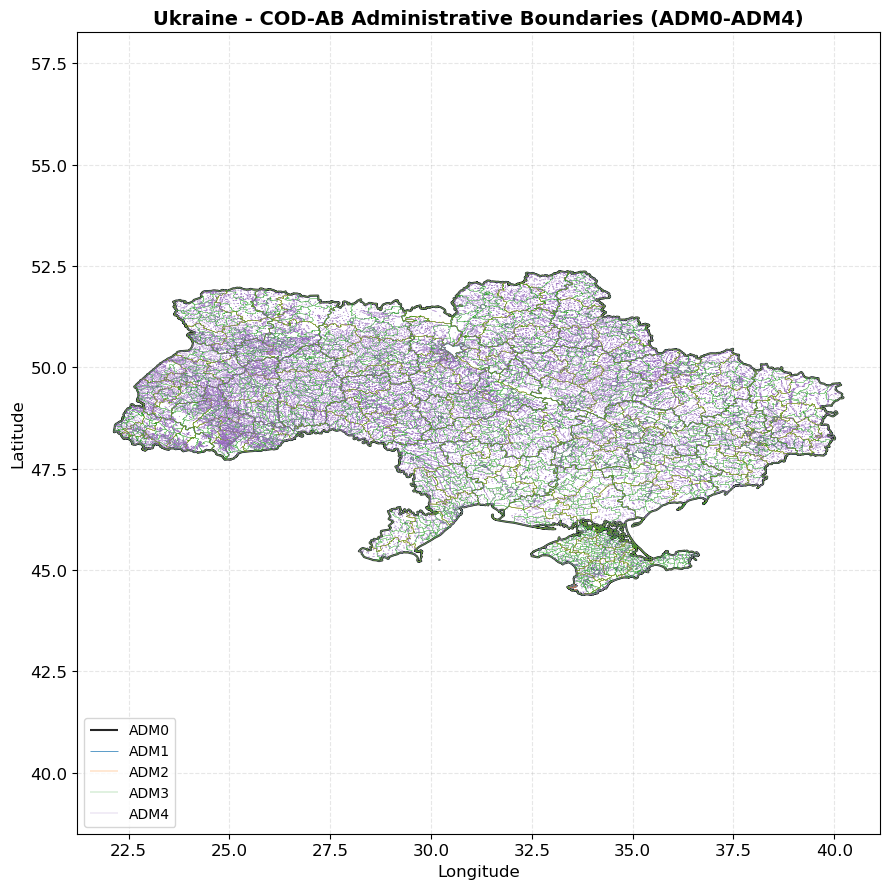


COD-AB LOADED (13.9s)
  Access: levels[0], levels[1], ... levels[4]


In [4]:
# @title CELL 6: LOAD COD-AB ADMINISTRATIVE BOUNDARIES (ADM0-ADM4)
# =============================================================================
# Loads COD-AB polygon layers (admbnda shapefiles) by admin level.
# Requires: Cell 4 + Cell 4A (paths)
# =============================================================================

CELL_ID = "cell_06_cod_ab_boundaries"
FORCE_RERUN = True

import os
import re
import glob
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
from datetime import datetime

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 6 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    for info in previous_log.get('levels_info', []):
        print(f"  ADM{info['level']}: {info['features']} features")
    levels = {}
else:
    start_time = datetime.now()

    print("=" * 70)
    print("LOADING COD-AB ADMINISTRATIVE BOUNDARIES")
    print("=" * 70)

    def load_cod_ab_areas(root):
        files = sorted(glob.glob(os.path.join(root, "**", "*.shp"), recursive=True))
        by_level = {}
        for f in files:
            base = os.path.basename(f).lower()
            if "admbnda" not in base:
                continue
            m = re.search(r"adm(\d)", base)
            if not m:
                continue
            lvl = int(m.group(1))
            g = gpd.read_file(f).to_crs(4326)
            g = g[g.geometry.notnull() & (~g.geometry.is_empty)]
            g = g[g.geom_type.isin(["Polygon", "MultiPolygon"])]
            if g.empty:
                continue
            print(f"  ADM{lvl}: {os.path.basename(f)} ({len(g)} features)")
            by_level[lvl] = g if lvl not in by_level else gpd.GeoDataFrame(
                pd.concat([by_level[lvl], g], ignore_index=True), crs=4326
            )
        return by_level

    print(f"\nSearching: {UKR_BOUNDARIES}")
    levels = load_cod_ab_areas(UKR_BOUNDARIES)

    if not levels:
        print("WARNING: No COD-AB polygon layers found. Check UKR_BOUNDARIES path.")
    else:
        print(f"\nLoaded {len(levels)} admin levels:")
        levels_info = []
        for lvl in sorted(levels):
            gdf = levels[lvl]
            print(f"  ADM{lvl}: {len(gdf)} features, bounds={gdf.total_bounds.round(2)}")
            levels_info.append({
                'level': lvl,
                'features': len(gdf),
                'crs': str(gdf.crs),
                'bounds': gdf.total_bounds.tolist()
            })

        # visualization
        fig, ax = plt.subplots(figsize=(9, 9))
        style = {
            0: ("black", 1.5),
            1: ("tab:blue", 0.6),
            2: ("tab:orange", 0.3),
            3: ("tab:green", 0.25),
            4: ("tab:purple", 0.2)
        }

        for lvl in sorted(levels):
            color, lw = style.get(lvl, ("gray", 0.3))
            levels[lvl].boundary.plot(ax=ax, color=color, linewidth=lw, alpha=0.85,
                                      aspect="auto", label=f"ADM{lvl}")

        ax.set_title("Ukraine - COD-AB Administrative Boundaries (ADM0-ADM4)", fontsize=14, fontweight='bold')
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.legend(loc="lower left", fontsize=10)
        ax.grid(True, alpha=0.3, linestyle='--')

        try:
            ax.set_aspect("equal", adjustable="datalim")
        except Exception:
            ax.set_aspect("auto")

        plt.tight_layout()

        fig_dir = Path(OUTPUTS_DIR) / CELL_ID
        fig_dir.mkdir(exist_ok=True)
        fig_path = fig_dir / "ukraine_cod_ab_boundaries.png"
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"\nSaved: {fig_path}")
        plt.show()
        plt.close()

        # log
        duration = (datetime.now() - start_time).total_seconds()
        log_data = {
            'cell_id': CELL_ID,
            'status': 'SUCCESS',
            'timestamp': datetime.now().isoformat(),
            'duration_seconds': duration,
            'levels_info': levels_info,
            'num_levels': len(levels),
            'total_features': sum(len(levels[lvl]) for lvl in levels),
        }
        with open(CELL_LOG_FILE, 'w') as f:
            json.dump(log_data, f, indent=2)

        print(f"\n{'='*70}")
        print(f"COD-AB LOADED ({duration:.1f}s)")
        print(f"  Access: levels[0], levels[1], ... levels[4]")
        print(f"{'='*70}")


plt.close('all')

# CELL 8: CREATE CITY BOUNDARIES + BATTLE DATES (NUCLEUS)

In [5]:
# @title CELL 8: CREATE CITY BOUNDARIES + BATTLE DATES (NUCLEUS)
# =============================================================================
# THIS IS THE FOUNDATIONAL CELL that creates all boundary.geojson files.
# It spatial-joins city coordinates to ADM3/ADM4 polygons and saves:
#   - CITIES_DIR/{city}/boundary.geojson (individual, with battle dates)
#   - DATA_ROOT/bda_city_boundaries.geojson (master file)
#   - DATA_ROOT/bda_battle_dates.json
#
# Properties per city: city_name, lat, lon, oblast, tier, priority,
#                      admin_level, battle_start, battle_stop, geometry
#
# Requires: Cell 4 + 4A (paths), Cell 6 optional (levels)
# =============================================================================

CELL_ID = "cell_08_city_boundaries"
FORCE_RERUN = True

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from shapely.geometry import Point
import json
from datetime import datetime
import glob
import math
import pyproj
from shapely.geometry import box as shapely_box
from shapely.ops import transform as shapely_transform

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"
CELL_IMAGE_DIR = Path(OUTPUTS_DIR) / CELL_ID
CELL_IMAGE_DIR.mkdir(exist_ok=True)

# ============================================================================
# CITIES CONFIG (battle dates, coords, tiers)
# ============================================================================
with open(CITIES_CONFIG_FILE) as f:
    cities_config = json.load(f)

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 8 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Cities: {previous_log.get('total_cities', '?')}, "
          f"Battle dates: {previous_log.get('cities_with_battle_dates', '?')}")

    # Load master boundaries into memory
    city_boundaries_file = Path(DATA_ROOT) / "bda_city_boundaries.geojson"
    if city_boundaries_file.exists():
        cities_gdf = gpd.read_file(city_boundaries_file)
        print(f"  Loaded cities_gdf: {len(cities_gdf)} cities")
    else:
        print(f"  WARNING: Master file missing, set FORCE_RERUN=True")

else:
    # ========================================================================
    # MAIN EXECUTION
    # ========================================================================
    start_time = datetime.now()

    print("=" * 70)
    print("CREATING CITY BOUNDARIES WITH BATTLE DATES")
    print("=" * 70)
    print(f"Total cities defined: {len(PRIORITY_CITIES_COORDS)}")
    print(f"Cities with battle dates: {len([c for c in PRIORITY_CITIES_COORDS if c['name'] in BATTLE_DATES])}")

    # Create GeoDataFrame from coordinates
    geometry = [Point(city['lon'], city['lat']) for city in PRIORITY_CITIES_COORDS]
    cities_points_gdf = gpd.GeoDataFrame(PRIORITY_CITIES_COORDS, geometry=geometry, crs='EPSG:4326')

    # Save city coordinates
    coords_json = Path(DATA_ROOT) / "bda_city_coordinates.json"
    with open(coords_json, 'w') as f:
        json.dump(PRIORITY_CITIES_COORDS, f, indent=2)
    print(f"\n  Saved coordinates: {coords_json}")

    coords_geojson = Path(DATA_ROOT) / "bda_city_coordinates.geojson"
    cities_points_gdf.to_file(coords_geojson, driver='GeoJSON')
    print(f"  Saved GeoJSON: {coords_geojson}")

    # ========================================================================
    # LOAD ADM3/ADM4 BOUNDARIES
    # ========================================================================

    print(f"\nLoading administrative boundaries...")

    adm3_files = list(Path(UKR_BOUNDARIES).glob("*adm3*.shp"))
    adm4_files = list(Path(UKR_BOUNDARIES).glob("*adm4*.shp"))

    if not adm3_files and not adm4_files:
        raise FileNotFoundError("No ADM3 or ADM4 boundary files found in UKR_BOUNDARIES")

    adm3_gdf = gpd.read_file(adm3_files[0]) if adm3_files else None
    adm4_gdf = gpd.read_file(adm4_files[0]) if adm4_files else None

    print(f"  ADM3: {len(adm3_gdf) if adm3_gdf is not None else 0} polygons")
    print(f"  ADM4: {len(adm4_gdf) if adm4_gdf is not None else 0} polygons")

    # Ensure same CRS
    ref_crs = adm3_gdf.crs if adm3_gdf is not None else adm4_gdf.crs
    cities_points_gdf = cities_points_gdf.to_crs(ref_crs)

    # ========================================================================
    # SPATIAL JOIN: MATCH CITIES TO ADM BOUNDARIES
    # ========================================================================

    print(f"\nMatching cities to administrative boundaries...")

    city_boundaries = []

    for idx, city_row in cities_points_gdf.iterrows():
        city_name = city_row['name']
        city_point = city_row.geometry
        battle_info = BATTLE_DATES.get(city_name, {})

        matched = False

        # Try ADM4 first (more granular)
        if adm4_gdf is not None:
            matching = adm4_gdf[adm4_gdf.contains(city_point)]
            if len(matching) > 0:
                city_boundaries.append({
                    'city_name': city_name,
                    'lat': city_row['lat'],
                    'lon': city_row['lon'],
                    'oblast': city_row['oblast'],
                    'tier': city_row['tier'],
                    'priority': city_row['priority'],
                    'admin_level': 'ADM4',
                    'battle_start': battle_info.get('battle_start', None),
                    'battle_stop': battle_info.get('battle_stop', None),
                    'geometry': matching.iloc[0].geometry
                })
                print(f"  {city_name:25s} ADM4  battle: {battle_info.get('battle_start', 'N/A')} to {battle_info.get('battle_stop', 'N/A')}")
                matched = True

        # Try ADM3 if ADM4 didn't match
        if not matched and adm3_gdf is not None:
            matching = adm3_gdf[adm3_gdf.contains(city_point)]
            if len(matching) > 0:
                city_boundaries.append({
                    'city_name': city_name,
                    'lat': city_row['lat'],
                    'lon': city_row['lon'],
                    'oblast': city_row['oblast'],
                    'tier': city_row['tier'],
                    'priority': city_row['priority'],
                    'admin_level': 'ADM3',
                    'battle_start': battle_info.get('battle_start', None),
                    'battle_stop': battle_info.get('battle_stop', None),
                    'geometry': matching.iloc[0].geometry
                })
                print(f"  {city_name:25s} ADM3  battle: {battle_info.get('battle_start', 'N/A')} to {battle_info.get('battle_stop', 'N/A')}")
                matched = True

        if not matched:
            print(f"  {city_name:25s} WARNING: no ADM boundary found")

    if not city_boundaries:
        raise RuntimeError("No city boundaries could be created")

    # Create GeoDataFrame
    cities_gdf = gpd.GeoDataFrame(city_boundaries, crs=ref_crs)

    print(f"\n  Created boundaries for {len(cities_gdf)}/{len(cities_points_gdf)} cities")
    print(f"  Admin level distribution: {cities_gdf['admin_level'].value_counts().to_dict()}")

    # Battle date statistics
    cities_with_dates = cities_gdf['battle_start'].notna().sum()
    ongoing_battles = (cities_gdf['battle_stop'] == 'ongoing').sum()
    completed_battles = ((cities_gdf['battle_stop'] != 'ongoing') & cities_gdf['battle_stop'].notna()).sum()

    print(f"\n  Battle dates: {cities_with_dates}/{len(cities_gdf)} cities")
    print(f"    Ongoing: {ongoing_battles}, Completed: {completed_battles}")
    # ========================================================================
    # COMPUTE PIXEL-ALIGNED BOUNDING BOXES (for patch generation)
    # ========================================================================
    # For each city polygon, project to UTM, compute bbox, then extend
    # width and height (in pixels at 10m) to the next multiple of 256.
    # 256 chosen so all patch sizes (256, 128, 64) tile evenly.
    # Stores aligned bbox properties in cities_gdf and saves per-city
    # AOI.geojson with bbox rectangle + city polygon.

    print(f"\nComputing 256-aligned bounding boxes...")

    bbox_results = {}

    for idx, row in cities_gdf.iterrows():
        city_name = row['city_name']
        city_geom = row.geometry

        # auto-detect UTM zone from city centroid
        centroid = city_geom.centroid
        utm_zone = int((centroid.x + 180) / 6) + 1
        hemisphere = 'north' if centroid.y >= 0 else 'south'
        utm_epsg = 32600 + utm_zone if hemisphere == 'north' else 32700 + utm_zone

        # project to UTM
        project_to_utm = pyproj.Transformer.from_crs('EPSG:4326', f'EPSG:{utm_epsg}', always_xy=True).transform
        project_to_wgs = pyproj.Transformer.from_crs(f'EPSG:{utm_epsg}', 'EPSG:4326', always_xy=True).transform
        city_geom_utm = shapely_transform(project_to_utm, city_geom)

        # bbox with buffer
        minx, miny, maxx, maxy = city_geom_utm.bounds
        minx -= BUFFER_M
        miny -= BUFFER_M
        maxx += BUFFER_M
        maxy += BUFFER_M

        # snap to 10m grid
        minx = math.floor(minx / TARGET_RES) * TARGET_RES
        miny = math.floor(miny / TARGET_RES) * TARGET_RES
        maxx = math.ceil(maxx / TARGET_RES) * TARGET_RES
        maxy = math.ceil(maxy / TARGET_RES) * TARGET_RES

        w_px = int(round((maxx - minx) / TARGET_RES))
        h_px = int(round((maxy - miny) / TARGET_RES))

        # pad to next multiple of 256
        d = PREFERRED_DIVISOR
        w_aligned = math.ceil(w_px / d) * d
        h_aligned = math.ceil(h_px / d) * d

        # distribute padding evenly on both sides
        pad_w = (w_aligned - w_px) * TARGET_RES
        pad_h = (h_aligned - h_px) * TARGET_RES
        minx -= pad_w / 2
        maxx += pad_w / 2
        miny -= pad_h / 2
        maxy += pad_h / 2

        # verify
        final_w = int(round((maxx - minx) / TARGET_RES))
        final_h = int(round((maxy - miny) / TARGET_RES))
        assert final_w % d == 0, f"{city_name}: width {final_w} not divisible by {d}"
        assert final_h % d == 0, f"{city_name}: height {final_h} not divisible by {d}"
        assert final_w == w_aligned
        assert final_h == h_aligned

        # create bbox geometry in WGS84
        bbox_utm = shapely_box(minx, miny, maxx, maxy)
        bbox_wgs84 = shapely_transform(project_to_wgs, bbox_utm)

        bbox_results[idx] = {
            'utm_epsg': utm_epsg,
            'utm_minx': minx,
            'utm_miny': miny,
            'utm_maxx': maxx,
            'utm_maxy': maxy,
            'width_px': final_w,
            'height_px': final_h,
            'divisor': d,
            'resolution_m': TARGET_RES,
            'bbox_geom_wgs84': bbox_wgs84,
        }

        pad_w_m = (final_w - w_px) * TARGET_RES
        pad_h_m = (final_h - h_px) * TARGET_RES
        print(f"  {city_name:25s} {final_w:5d}x{final_h:<5d} px  pad +{pad_w_m:.0f}m x +{pad_h_m:.0f}m  EPSG:{utm_epsg}")

    # add bbox columns to cities_gdf
    for col in ['bbox_utm_epsg', 'bbox_utm_minx', 'bbox_utm_miny', 'bbox_utm_maxx', 'bbox_utm_maxy',
                'bbox_width_px', 'bbox_height_px', 'bbox_divisor', 'bbox_resolution_m']:
        cities_gdf[col] = None

    for idx, binfo in bbox_results.items():
        cities_gdf.at[idx, 'bbox_utm_epsg'] = binfo['utm_epsg']
        cities_gdf.at[idx, 'bbox_utm_minx'] = binfo['utm_minx']
        cities_gdf.at[idx, 'bbox_utm_miny'] = binfo['utm_miny']
        cities_gdf.at[idx, 'bbox_utm_maxx'] = binfo['utm_maxx']
        cities_gdf.at[idx, 'bbox_utm_maxy'] = binfo['utm_maxy']
        cities_gdf.at[idx, 'bbox_width_px'] = binfo['width_px']
        cities_gdf.at[idx, 'bbox_height_px'] = binfo['height_px']
        cities_gdf.at[idx, 'bbox_divisor'] = binfo['divisor']
        cities_gdf.at[idx, 'bbox_resolution_m'] = binfo['resolution_m']

    print(f"\n  Added 9 bbox columns to cities_gdf")
    print(f"  All {len(bbox_results)} cities aligned to {PREFERRED_DIVISOR}px divisor")

    # ========================================================================
    # SAVE MASTER OUTPUTS
    # ========================================================================

    output_geojson = Path(DATA_ROOT) / "bda_city_boundaries.geojson"
    cities_gdf.to_file(output_geojson, driver='GeoJSON')
    print(f"\n  Master GeoJSON: {output_geojson}")

    output_shp = Path(DATA_ROOT) / "bda_city_boundaries.shp"
    cities_gdf.to_file(output_shp)
    print(f"  Master Shapefile: {output_shp}")

    # ========================================================================
    # SAVE INDIVIDUAL CITY BOUNDARIES
    # ========================================================================

    print(f"\nSaving individual city boundaries...")

    cities_dir = Path(CITIES_DIR)
    cities_dir.mkdir(exist_ok=True)

    individual_files_created = []

    for idx, row in cities_gdf.iterrows():
        city_name = row['city_name']
        city_dir = cities_dir / city_name
        city_dir.mkdir(exist_ok=True)

        # --- boundary.geojson: city polygon (kept for backward compat) ---
        city_single_gdf = cities_gdf.iloc[[idx]].copy()
        city_boundary_file = city_dir / "boundary.geojson"
        city_single_gdf.to_file(city_boundary_file, driver='GeoJSON')

        # --- AOI.geojson: bbox rectangle + city polygon in one file ---
        # Later cells (12B2, 18B) will enrich this with buildings + damage labels
        binfo = bbox_results[idx]

        # feature 1: aoi_bbox rectangle
        bbox_feature = {
            'feature_type': 'aoi_bbox',
            'city_name': city_name,
            'utm_epsg': binfo['utm_epsg'],
            'utm_minx': binfo['utm_minx'],
            'utm_miny': binfo['utm_miny'],
            'utm_maxx': binfo['utm_maxx'],
            'utm_maxy': binfo['utm_maxy'],
            'width_px': binfo['width_px'],
            'height_px': binfo['height_px'],
            'divisor': binfo['divisor'],
            'resolution_m': binfo['resolution_m'],
            'geometry': binfo['bbox_geom_wgs84'],
        }

        # feature 2: city_polygon (admin boundary)
        poly_props = {
            'feature_type': 'city_polygon',
            'city_name': city_name,
            'oblast': row['oblast'],
            'tier': row['tier'],
            'priority': row['priority'],
            'admin_level': row['admin_level'],
            'battle_start': row['battle_start'],
            'battle_stop': row['battle_stop'],
            'geometry': row.geometry,
        }

        aoi_gdf = gpd.GeoDataFrame([bbox_feature, poly_props], crs='EPSG:4326')
        aoi_file = city_dir / "AOI.geojson"
        aoi_gdf.to_file(aoi_file, driver='GeoJSON')

        battle_info = f"{row['battle_start']} to {row['battle_stop']}" if row['battle_start'] else "No dates"
        print(f"  {city_name:25s} -> boundary.geojson + AOI.geojson ({battle_info})")
        individual_files_created.append(str(city_boundary_file.relative_to(DATA_ROOT)))
    print(f"\n  Saved {len(cities_gdf)} individual boundary files")

    # Save battle dates separately
    battle_dates_file = Path(DATA_ROOT) / "bda_battle_dates.json"
    with open(battle_dates_file, 'w') as f:
        json.dump(BATTLE_DATES, f, indent=2)
    print(f"  Battle dates: {battle_dates_file}")

    # Save metadata
    metadata = {
        'created': pd.Timestamp.now().isoformat(),
        'total_cities_requested': len(cities_points_gdf),
        'total_cities_matched': len(cities_gdf),
        'cities_with_battle_dates': int(cities_with_dates),
        'ongoing_battles': int(ongoing_battles),
        'completed_battles': int(completed_battles),
        'admin_levels': cities_gdf['admin_level'].value_counts().to_dict(),
        'tier_distribution': {str(k): v for k, v in cities_gdf.groupby('tier').size().to_dict().items()},
        'oblast_distribution': cities_gdf.groupby('oblast').size().to_dict(),
    }

    metadata_file = Path(DATA_ROOT) / "bda_city_boundaries_metadata.json"
    with open(metadata_file, 'w') as f:
        json.dump(metadata, f, indent=2)

    # ========================================================================
    # VISUALIZATION
    # ========================================================================

    fig, ax = plt.subplots(figsize=(16, 12))

    # Ukraine outline
    adm0_files = list(Path(UKR_BOUNDARIES).glob("*adm0*.shp"))
    if adm0_files:
        adm0_gdf = gpd.read_file(adm0_files[0])
        adm0_gdf.plot(ax=ax, facecolor='lightgray', edgecolor='black', linewidth=1, alpha=0.3)

    # Cities by tier
    tier_colors = {0: 'darkred', 1: 'red', 2: 'orange', 3: 'yellow'}
    tier_labels = {0: 'Tier 0: Primary Analysis', 1: 'Tier 1: Complete Destruction', 2: 'Tier 2: Severe Damage', 3: 'Tier 3: Moderate Damage'}

    for tier in [0, 1, 2, 3]:
        tier_cities = cities_gdf[cities_gdf['tier'] == tier]
        if len(tier_cities) > 0:
            tier_cities.plot(ax=ax, color=tier_colors[tier], edgecolor='black',
                           alpha=0.5, linewidth=1, label=tier_labels[tier])

    # Labels for priority 1 cities
    priority1 = cities_gdf[cities_gdf['priority'] == 1]
    for idx, row in priority1.iterrows():
        centroid = row.geometry.centroid
        ax.annotate(row['city_name'], xy=(centroid.x, centroid.y),
                   fontsize=7, ha='center', fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='black'))

    ax.set_title('BDA Priority Cities - Administrative Boundaries with Battle Dates', fontsize=16, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()

    fig_path = CELL_IMAGE_DIR / "bda_city_boundaries_map.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"\n  Saved: {fig_path}")

    # ========================================================================
    # SUMMARY
    # ========================================================================

    cities_utm = cities_gdf.to_crs('EPSG:32636')
    total_area_km2 = cities_utm.geometry.area.sum() / 1_000_000
    avg_area_km2 = total_area_km2 / len(cities_gdf)

    duration = (datetime.now() - start_time).total_seconds()

    print(f"\n{'='*70}")
    print(f"CITY BOUNDARIES COMPLETE ({duration:.1f}s)")
    print(f"{'='*70}")
    print(f"  Total cities: {len(cities_gdf)}")
    for tier in [0, 1, 2, 3]:
        print(f"    Tier {tier}: {len(cities_gdf[cities_gdf['tier'] == tier])} cities")
    print(f"  Total area: {total_area_km2:.1f} km2, avg: {avg_area_km2:.1f} km2/city")

    print(f"\n  By oblast:")
    for oblast, count in cities_gdf['oblast'].value_counts().items():
        print(f"    {oblast:20s}: {count}")

    # Save log
    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'total_cities': len(cities_gdf),
        'cities_with_battle_dates': int(cities_with_dates),
        'cities_by_tier': {str(k): v for k, v in cities_gdf['tier'].value_counts().to_dict().items()},
        'cities_by_oblast': cities_gdf['oblast'].value_counts().to_dict(),
        'admin_levels': cities_gdf['admin_level'].value_counts().to_dict(),
        'total_area_km2': float(total_area_km2),
        'avg_area_km2': float(avg_area_km2),
        'individual_city_files': individual_files_created,
        'bbox_divisor': PREFERRED_DIVISOR,
        'bbox_resolution_m': TARGET_RES,
        'bbox_buffer_m': BUFFER_M,
    }

    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n  cities_gdf available with {len(cities_gdf)} cities")
    print(f"  Access: cities_gdf[['city_name', 'battle_start', 'battle_stop', 'tier']]")
    print(f"{'='*70}")

plt.close('all') 

CREATING CITY BOUNDARIES WITH BATTLE DATES
Total cities defined: 50
Cities with battle dates: 50

  Saved coordinates: /content/drive_f/masterthesis/data/bda_city_coordinates.json
  Saved GeoJSON: /content/drive_f/masterthesis/data/bda_city_coordinates.geojson

Loading administrative boundaries...
  ADM3: 1769 polygons
  ADM4: 29707 polygons

Matching cities to administrative boundaries...
  Mariupol                  ADM4  battle: 2022-02-24 to 2022-05-20
  Bakhmut                   ADM4  battle: 2022-05-17 to 2023-05-20
  Avdiivka                  ADM4  battle: 2022-02-24 to 2024-02-17
  Sievierodonetsk           ADM4  battle: 2022-05-05 to 2022-06-25
  Maryinka                  ADM4  battle: 2022-02-24 to 2023-12-25
  Soledar                   ADM4  battle: 2022-07-01 to 2023-01-16
  Vuhledar                  ADM4  battle: 2022-02-24 to 2024-10-02
  Volnovakha                ADM4  battle: 2022-02-24 to 2022-03-12
  Pisky                     ADM4  battle: 2022-02-24 to 2022-08-24
  Kr

# CELL 12B: DOWNLOAD OVERTURE BUILDING FOOTPRINTS PER CITY


In [6]:
# @title CELL 12B: DOWNLOAD OVERTURE BUILDING FOOTPRINTS PER CITY
# =============================================================================
# Downloads Overture Maps building footprints (Microsoft+Google+OSM conflation)
# for all 50 BDA cities using bounding boxes from city boundaries.
# Compares coverage vs OSM buildings from Cell 9/10.
# CLIP_MODE controls post-download clip: "bbox" keeps raw download,
# "polygon" clips to city boundary polygon before saving.
#
# Output: OVERTURE_DIR/{city}_buildings_overture.geojson
# Requires: Cell 8 (bda_city_boundaries.geojson), pip install overturemaps
# =============================================================================

CELL_ID = "cell_12b_download_overture_buildings"
FORCE_RERUN = False

import geopandas as gpd
import pandas as pd
from pathlib import Path
import json
import subprocess
from datetime import datetime

OVERTURE_DIR.mkdir(exist_ok=True)

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"

assert CLIP_MODE in ("bbox", "polygon"), f"CLIP_MODE must be 'bbox' or 'polygon', got '{CLIP_MODE}'"

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 12B already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Cities downloaded: {previous_log.get('cities_downloaded', '?')}")

else:
    start_time = datetime.now()

    print("=" * 70)
    print(f"DOWNLOADING OVERTURE BUILDING FOOTPRINTS PER CITY (CLIP_MODE={CLIP_MODE})")
    print("=" * 70)

    # Ensure overturemaps CLI is installed
    try:
        result = subprocess.run(['overturemaps', '--help'], capture_output=True, text=True)
        print(f"  overturemaps CLI available")
    except FileNotFoundError:
        print(f"  Installing overturemaps CLI...")
        subprocess.run(['pip', 'install', 'overturemaps', '--break-system-packages'],
                      capture_output=True, text=True)
        print(f"  Installed")

    # Load city boundaries
    city_boundaries_file = Path(DATA_ROOT) / "bda_city_boundaries.geojson"
    cities_gdf = gpd.read_file(city_boundaries_file)
    print(f"  Loaded {len(cities_gdf)} city boundaries")

    # ========================================================================
    # DOWNLOAD PER CITY
    # ========================================================================

    city_stats = []

    for idx, city_row in cities_gdf.iterrows():
        city_name = city_row['city_name']
        output_file = OVERTURE_DIR / f"{city_name}_buildings_overture.geojson"

        if output_file.exists() and not FORCE_RERUN:
            # Count existing features
            try:
                existing = gpd.read_file(output_file)
                count = len(existing)
                print(f"  {city_name:25s}: {count:,} buildings (cached)")
                city_stats.append({'city': city_name, 'overture_count': count, 'status': 'cached'})
                continue
            except Exception:
                pass

        # Get bounding box
        bounds = city_row.geometry.bounds  # minx, miny, maxx, maxy
        bbox = f"{bounds[0]},{bounds[1]},{bounds[2]},{bounds[3]}"

        print(f"  {city_name:25s}: downloading (bbox={bbox[:40]})...", end='', flush=True)

        try:
            result = subprocess.run(
                ['overturemaps', 'download',
                 '--bbox', bbox,
                 '-f', 'geojson',
                 '--type', 'building',
                 '-o', str(output_file)],
                capture_output=True, text=True, timeout=300
            )

            if result.returncode != 0:
                print(f" ERROR: {result.stderr[:100]}")
                city_stats.append({'city': city_name, 'overture_count': 0, 'status': 'error',
                                   'error': result.stderr[:200]})
                continue

            overture_gdf = gpd.read_file(output_file)

            if CLIP_MODE == "polygon" and len(overture_gdf) > 0:
                city_geom = city_row.geometry
                if overture_gdf.crs != cities_gdf.crs:
                    overture_gdf = overture_gdf.to_crs(cities_gdf.crs)
                overture_gdf = overture_gdf[overture_gdf.geometry.intersects(city_geom)]
                overture_gdf.to_file(output_file, driver='GeoJSON')

            count = len(overture_gdf)
            size_mb = output_file.stat().st_size / (1024**2)

            # Compare with OSM
            osm_file = OSM_OUTPUT_DIR / f"{city_name}_buildings_2025.geojson"
            osm_count = 0
            if osm_file.exists():
                osm_gdf = gpd.read_file(osm_file)
                osm_count = len(osm_gdf)

            ratio = count / osm_count if osm_count > 0 else float('inf')
            print(f" {count:,} buildings ({size_mb:.1f} MB) | OSM: {osm_count:,} | ratio: {ratio:.2f}x")

            city_stats.append({
                'city': city_name,
                'overture_count': count,
                'osm_count': osm_count,
                'ratio': float(ratio),
                'size_mb': float(size_mb),
                'status': 'ok'
            })

        except subprocess.TimeoutExpired:
            print(f" TIMEOUT")
            city_stats.append({'city': city_name, 'overture_count': 0, 'status': 'timeout'})
        except Exception as e:
            print(f" ERROR: {e}")
            city_stats.append({'city': city_name, 'overture_count': 0, 'status': 'error', 'error': str(e)})

    # ========================================================================
    # SUMMARY
    # ========================================================================

    stats_df = pd.DataFrame(city_stats)
    stats_df.to_csv(OVERTURE_DIR / "download_summary.csv", index=False)

    ok_cities = stats_df[stats_df['status'].isin(['ok', 'cached'])]
    total_overture = ok_cities['overture_count'].sum()
    total_osm = ok_cities['osm_count'].sum() if 'osm_count' in ok_cities.columns else 0

    duration = (datetime.now() - start_time).total_seconds()

    print(f"\n{'='*70}")
    print(f"OVERTURE DOWNLOAD COMPLETE ({duration:.1f}s)")
    print(f"{'='*70}")
    print(f"  Clip mode: {CLIP_MODE}")
    print(f"  Cities downloaded: {len(ok_cities)}/{len(cities_gdf)}")
    print(f"  Total Overture buildings: {total_overture:,}")
    if total_osm > 0:
        print(f"  Total OSM buildings:      {total_osm:,}")
        print(f"  Overall ratio:            {total_overture/total_osm:.2f}x")

    if 'ratio' in ok_cities.columns:
        print(f"\n  Cities where Overture > 2x OSM (biggest coverage gaps):")
        big_gaps = ok_cities[ok_cities['ratio'] > 2.0].sort_values('ratio', ascending=False)
        for _, row in big_gaps.iterrows():
            print(f"    {row['city']:25s}: Overture={row['overture_count']:,}, "
                  f"OSM={row.get('osm_count', 0):,}, ratio={row['ratio']:.2f}x")

    errors = stats_df[stats_df['status'].isin(['error', 'timeout'])]
    if len(errors) > 0:
        print(f"\n  Failed cities ({len(errors)}):")
        for _, row in errors.iterrows():
            print(f"    {row['city']}: {row['status']}")

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'clip_mode': CLIP_MODE,
        'cities_downloaded': int(len(ok_cities)),
        'total_overture_buildings': int(total_overture),
        'total_osm_buildings': int(total_osm),
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"{'='*70}")

CELL 12B already run (2026-03-21). Set FORCE_RERUN=True to re-run.
  Cities downloaded: 50


# 12B2: CLIP OVERTURE BUILDINGS TO CITY BBOX

In [7]:
# @title CELL 12B2: CLIP OVERTURE BUILDINGS TO CITY EXTENT
# =============================================================================
# Clips raw Overture bbox downloads to city extent.
# CLIP_MODE controls spatial clip: "bbox" or "polygon".
# OSM buildings are already clipped (downloaded per city in Cell 9/10).
#
# Output: OVERTURE_DIR/clipped/{city}_buildings_overture.geojson
#         DATA_ROOT/cities/{city}/{city}_buildings_overture.geojson
# Requires: Cell 12B (Overture download), Cell 8 (boundaries)
# =============================================================================

CELL_ID = "cell_12b2_clip_overture_to_boundaries"
FORCE_RERUN = True

import geopandas as gpd
import pandas as pd
from pathlib import Path
import json
from datetime import datetime
from shapely.geometry import box

OVERTURE_CLIPPED.mkdir(exist_ok=True)

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"

assert CLIP_MODE in ("bbox", "polygon"), f"CLIP_MODE must be 'bbox' or 'polygon', got '{CLIP_MODE}'"

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 12B2 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Cities clipped: {previous_log.get('cities_clipped', '?')}")

else:
    start_time = datetime.now()

    print("=" * 70)
    print(f"CLIPPING OVERTURE BUILDINGS TO CITY EXTENT (CLIP_MODE={CLIP_MODE})")
    print("=" * 70)

    city_boundaries_file = Path(DATA_ROOT) / "bda_city_boundaries.geojson"
    cities_gdf = gpd.read_file(city_boundaries_file)
    print(f"  Loaded {len(cities_gdf)} city boundaries")

    print(f"\n  {'City':25s} {'Raw':>9s} {'Clipped':>9s} {'Dropped':>9s} {'Drop%':>7s}")
    print(f"  {'-'*65}")

    clip_stats = []

    for idx, city_row in cities_gdf.iterrows():
        city_name = city_row['city_name']
        boundary = city_row.geometry

        ov_raw_file = OVERTURE_DIR / f"{city_name}_buildings_overture.geojson"
        ov_clip_file = OVERTURE_CLIPPED / f"{city_name}_buildings_overture.geojson"

        ov_raw_n = 0
        ov_clip_n = 0

        if not ov_raw_file.exists():
            print(f"  {city_name:25s} {'n/a':>9s}")
            clip_stats.append({'city_name': city_name, 'raw': 0, 'clipped': 0, 'dropped_pct': 0})
            continue

        if ov_clip_file.exists() and not FORCE_RERUN:
            ov_raw_n = len(gpd.read_file(ov_raw_file))
            ov_clip_n = len(gpd.read_file(ov_clip_file))
        else:
            ov_gdf = gpd.read_file(ov_raw_file)
            ov_raw_n = len(ov_gdf)
            if ov_raw_n > 0:
                if ov_gdf.crs != cities_gdf.crs:
                    ov_gdf = ov_gdf.to_crs(cities_gdf.crs)
                if CLIP_MODE == "bbox":
                    clip_geom = box(*boundary.bounds)
                    mask = ov_gdf.geometry.within(clip_geom)
                else:
                    clip_geom = boundary
                    mask = ov_gdf.geometry.intersects(clip_geom)
                ov_clipped = ov_gdf[mask]
                ov_clip_n = len(ov_clipped)
                ov_clipped.to_file(ov_clip_file, driver='GeoJSON')
                # Also save to per-city directory
                city_dir = Path(DATA_ROOT) / "cities" / city_name
                city_dir.mkdir(parents=True, exist_ok=True)
                ov_clipped.to_file(city_dir / f"{city_name}_buildings_overture.geojson", driver='GeoJSON')

        dropped = ov_raw_n - ov_clip_n
        drop_pct = dropped / ov_raw_n * 100 if ov_raw_n > 0 else 0

        print(f"  {city_name:25s} {ov_raw_n:>9,} {ov_clip_n:>9,} {dropped:>9,} {drop_pct:>6.1f}%")

        clip_stats.append({
            'city_name': city_name,
            'raw': int(ov_raw_n),
            'clipped': int(ov_clip_n),
            'dropped_pct': float(drop_pct)
        })

    stats_df = pd.DataFrame(clip_stats)
    stats_df.to_csv(OVERTURE_DIR / "clip_statistics.csv", index=False)

    total_raw = stats_df['raw'].sum()
    total_clip = stats_df['clipped'].sum()

    duration = (datetime.now() - start_time).total_seconds()

    cities_clipped = len(stats_df[stats_df['clipped'] > 0])

    print(f"\n{'='*70}")
    print(f"CLIPPING COMPLETE ({duration:.1f}s)")
    print(f"{'='*70}")
    print(f"  Clip mode: {CLIP_MODE}")
    print(f"  Overture: {total_raw:,} -> {total_clip:,} "
          f"(dropped {total_raw - total_clip:,}, {(total_raw - total_clip)/total_raw*100:.1f}%)")
    print(f"  Output: {OVERTURE_CLIPPED}")
    print(f"  Also saved to: {Path(DATA_ROOT) / 'cities' / '<city>'}")
    print(f"{'='*70}")

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'clip_mode': CLIP_MODE,
        'cities_clipped': int(cities_clipped),
        'overture_raw': int(total_raw),
        'overture_clipped': int(total_clip),
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

CLIPPING OVERTURE BUILDINGS TO CITY EXTENT (CLIP_MODE=bbox)
  Loaded 50 city boundaries

  City                            Raw   Clipped   Dropped   Drop%
  -----------------------------------------------------------------
  Mariupol                    119,119   119,107        12    0.0%
  Bakhmut                      29,232    29,221        11    0.0%
  Avdiivka                     13,367    13,360         7    0.1%
  Sievierodonetsk              14,222    14,151        71    0.5%
  Maryinka                      8,757     8,678        79    0.9%
  Soledar                       6,542     6,522        20    0.3%
  Vuhledar                      2,773     2,765         8    0.3%
  Volnovakha                   13,895    13,888         7    0.1%
  Pisky                         1,134     1,128         6    0.5%
  Krasnohorivka                59,766    59,689        77    0.1%
  New York                     80,092    79,999        93    0.1%
  Toretsk                      12,239    12,220    

# CELL 15: EXTRACT UNOSAT DAMAGE DATA PER CITY

In [8]:
# @title CELL 15: EXTRACT UNOSAT DAMAGE DATA PER CITY
# =============================================================================
# Loads Dietrich compiled UNOSAT labels (unosat_labels.geojson, 18,686 points),
# spatial-joins to each city extent, saves per-city GeoJSON + metadata.
# CLIP_MODE controls spatial extraction: "bbox" or "polygon".
# Also loads original Mariupol shapefile for comparison if available.
# Output: UNOSAT_CITIES_DIR/{city}/unosat_damage.geojson, unosat_metadata.json
#
# Requires: Cell 8 (bda_city_boundaries.geojson), Cell 13/14 (UNOSAT download)
# =============================================================================

CELL_ID = "cell_15_extract_unosat_cities"
FORCE_RERUN = True

import geopandas as gpd
import pandas as pd
from pathlib import Path
import json
from datetime import datetime
from shapely.geometry import box


UNOSAT_CITIES_DIR.mkdir(exist_ok=True)

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"

assert CLIP_MODE in ("bbox", "polygon"), f"CLIP_MODE must be 'bbox' or 'polygon', got '{CLIP_MODE}'"

# Dietrich damage code mapping (from compiled GDB inspection)
# Codes observed: 1,2,3,4,5,6,7,15
DAMAGE_CODE_MAP = {
    1: 'Possibly Damaged',
    2: 'Moderately Damaged',
    3: 'Severely Damaged',
    4: 'Destroyed',
    5: 'Impact Crater',
    6: 'No Visible Damage',
    7: 'No Visible Damage',
    15: 'Unknown'
}

# Binary label for ML: damaged (destroyed + severely damaged) vs undamaged
# Following Dietrich 2025 who merges destroyed+severely into "damaged"
DAMAGE_BINARY_MAP = {
    1: 0,  # Possibly Damaged -> undamaged
    2: 0,  # Moderately Damaged -> undamaged
    3: 1,  # Severely Damaged -> damaged
    4: 1,  # Destroyed -> damaged
    5: -1, # Impact Crater -> exclude
    6: 0,  # No Visible Damage -> undamaged
    7: 0,  # No Visible Damage -> undamaged
    15: -1 # Unknown -> exclude
}

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 15 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Cities with data: {previous_log.get('cities_with_data', '?')}, "
          f"Features: {previous_log.get('total_features', '?'):,}")

else:
    # ========================================================================
    # MAIN EXECUTION
    # ========================================================================
    start_time = datetime.now()

    print("=" * 70)
    print(f"EXTRACTING UNOSAT BUILDING DAMAGE DATA PER CITY (CLIP_MODE={CLIP_MODE})")
    print("=" * 70)

    # Load city boundaries
    city_boundaries_file = Path(DATA_ROOT) / "bda_city_boundaries.geojson"
    cities_gdf = gpd.read_file(city_boundaries_file)
    print(f"  Loaded {len(cities_gdf)} city boundaries, CRS={cities_gdf.crs}")

    # ========================================================================
    # LOAD DIETRICH COMPILED LABELS (PRIMARY SOURCE)
    # ========================================================================

    dietrich_labels_file = UNOSAT_RAW_DIR / "unosat_labels.geojson"
    dietrich_aois_file = UNOSAT_RAW_DIR / "unosat_aois.geojson"

    if not dietrich_labels_file.exists():
        raise FileNotFoundError(f"Dietrich compiled labels not found: {dietrich_labels_file}")

    print(f"\n  Loading Dietrich compiled UNOSAT labels...")
    unosat_all = gpd.read_file(dietrich_labels_file)
    print(f"  Loaded {len(unosat_all):,} features, CRS={unosat_all.crs}")
    print(f"  Columns: {list(unosat_all.columns)}")
    print(f"  AOIs: {unosat_all['aoi'].nunique()} unique ({unosat_all['aoi'].value_counts().to_dict()})")

    # Add mapped damage columns
    unosat_all['damage_label'] = unosat_all['damage'].map(DAMAGE_CODE_MAP)
    unosat_all['damage_binary'] = unosat_all['damage'].map(DAMAGE_BINARY_MAP)

    print(f"\n  Damage code distribution:")
    for code, count in unosat_all['damage'].value_counts().sort_index().items():
        label = DAMAGE_CODE_MAP.get(code, '?')
        binary = DAMAGE_BINARY_MAP.get(code, '?')
        print(f"    {code:3d} = {label:25s} (binary={binary:2d}): {count:,}")

    n_damaged = (unosat_all['damage_binary'] == 1).sum()
    n_undamaged = (unosat_all['damage_binary'] == 0).sum()
    n_excluded = (unosat_all['damage_binary'] == -1).sum()
    print(f"\n  Binary split: damaged={n_damaged:,}, undamaged={n_undamaged:,}, excluded={n_excluded:,}")

    # Load AOI boundaries for reference
    if dietrich_aois_file.exists():
        aois_gdf = gpd.read_file(dietrich_aois_file)
        print(f"  Loaded {len(aois_gdf)} AOI boundaries")
    else:
        aois_gdf = None
        print(f"  WARNING: AOI boundaries not found")

    # ========================================================================
    # LOAD ORIGINAL MARIUPOL SHAPEFILE (COMPARISON)
    # ========================================================================

    mariupol_original = None
    for shp_file in UNOSAT_RAW_DIR.glob("**/*Damage_Point*No_Military*.shp"):
        print(f"\n  Found original Mariupol shapefile: {shp_file.name}")
        mariupol_original = gpd.read_file(shp_file)
        print(f"  Original Mariupol: {len(mariupol_original):,} features")
        if 'Main_Damag' in mariupol_original.columns:
            print(f"  Main_Damag distribution: {mariupol_original['Main_Damag'].value_counts().sort_index().to_dict()}")
        break

    # Reproject to match city boundaries
    if unosat_all.crs != cities_gdf.crs:
        print(f"\n  Reprojecting from {unosat_all.crs} to {cities_gdf.crs}...")
        unosat_all = unosat_all.to_crs(cities_gdf.crs)
    if mariupol_original is not None and mariupol_original.crs != cities_gdf.crs:
        mariupol_original = mariupol_original.to_crs(cities_gdf.crs)

    # ========================================================================
    # EXTRACT PER CITY
    # ========================================================================

    print(f"\nExtracting per city...")

    city_extractions = []

    for idx, city_row in cities_gdf.iterrows():
        city_name = city_row['city_name']
        city_dir = UNOSAT_CITIES_DIR / city_name
        city_dir.mkdir(exist_ok=True)

        try:
            if CLIP_MODE == "bbox":
                clip_geom = box(*city_row.geometry.bounds)
            else:
                clip_geom = city_row.geometry
            clip_gdf = gpd.GeoDataFrame(geometry=[clip_geom], crs=cities_gdf.crs)

            city_damage = gpd.sjoin(unosat_all, clip_gdf, how='inner', predicate='within')
            city_damage = city_damage[[col for col in city_damage.columns if not col.startswith('index_')]]

            count = len(city_damage)

            if count > 0:
                city_damage.to_file(city_dir / "unosat_damage.geojson", driver='GeoJSON')
                # boundary.geojson is written by Cell 8 (nucleus) - do not overwrite here

                n_dam = (city_damage['damage_binary'] == 1).sum()
                n_undam = (city_damage['damage_binary'] == 0).sum()
                n_excl = (city_damage['damage_binary'] == -1).sum()
                aois_present = city_damage['aoi'].unique().tolist()
                epochs = city_damage['ep'].unique().tolist()

                print(f"  {city_name:25s}: {count:,} features "
                      f"(damaged={n_dam}, undamaged={n_undam}, excluded={n_excl}) "
                      f"AOIs={aois_present}")

                # Mariupol comparison
                mariupol_comparison = None
                if city_name == 'Mariupol' and mariupol_original is not None:
                    mar_sjoin = gpd.sjoin(mariupol_original, clip_gdf, how='inner', predicate='within')
                    mariupol_comparison = {
                        'original_shapefile_count': len(mar_sjoin),
                        'dietrich_compiled_count': count,
                        'clip_mode': CLIP_MODE,
                        'note': 'Dietrich compiled includes multiple assessment epochs and Livoberezhnyy district'
                    }
                    print(f"    -> Mariupol comparison: original={len(mar_sjoin)}, dietrich={count}")

                metadata = {
                    'city_name': city_name,
                    'oblast': city_row['oblast'],
                    'tier': int(city_row['tier']),
                    'priority': int(city_row['priority']),
                    'clip_mode': CLIP_MODE,
                    'damage_features': int(count),
                    'n_damaged': int(n_dam),
                    'n_undamaged': int(n_undam),
                    'n_excluded': int(n_excl),
                    'aois': aois_present,
                    'epochs': [int(e) for e in epochs],
                    'damage_distribution': city_damage['damage'].value_counts().sort_index().to_dict(),
                    'source': 'dietrich_compiled_unosat_labels',
                    'source_file': dietrich_labels_file.name,
                    'columns': list(city_damage.columns),
                    'geometry_type': 'Point',
                    'extracted_date': datetime.now().isoformat(),
                    'has_data': True
                }
                if mariupol_comparison:
                    metadata['mariupol_comparison'] = mariupol_comparison
            else:
                metadata = {
                    'city_name': city_name,
                    'oblast': city_row['oblast'],
                    'tier': int(city_row['tier']),
                    'priority': int(city_row['priority']),
                    'clip_mode': CLIP_MODE,
                    'damage_features': 0,
                    'extracted_date': datetime.now().isoformat(),
                    'has_data': False
                }

            with open(city_dir / "unosat_metadata.json", 'w') as f:
                json.dump(metadata, f, indent=2)

            city_extractions.append(metadata)

        except Exception as e:
            print(f"  {city_name:25s}: ERROR - {e}")
            city_extractions.append({
                'city_name': city_name,
                'error': str(e),
                'has_data': False,
                'damage_features': 0
            })

    # ========================================================================
    # SAVE AOI BOUNDARIES PER CITY (for reference)
    # ========================================================================

    if aois_gdf is not None:
        aoi_match_file = UNOSAT_CITIES_DIR / "city_aoi_mapping.json"
        city_aoi_map = {}
        for ext in city_extractions:
            if ext.get('has_data') and 'aois' in ext:
                city_aoi_map[ext['city_name']] = ext['aois']
        with open(aoi_match_file, 'w') as f:
            json.dump(city_aoi_map, f, indent=2)
        print(f"\n  Saved city-AOI mapping: {aoi_match_file.name}")

    # ========================================================================
    # SUMMARY
    # ========================================================================

    summary_df = pd.DataFrame(city_extractions)
    summary_df['has_data'] = summary_df['has_data'].astype(bool)
    summary_df['damage_features'] = summary_df['damage_features'].fillna(0).astype(int)

    cities_with_data = summary_df[summary_df['has_data'] == True]
    cities_without = summary_df[summary_df['has_data'] == False]

    summary_df.to_csv(UNOSAT_CITIES_DIR / "extraction_summary.csv", index=False)

    duration = (datetime.now() - start_time).total_seconds()

    print(f"\n{'='*70}")
    print(f"UNOSAT EXTRACTION COMPLETE ({duration:.1f}s)")
    print(f"{'='*70}")
    print(f"  Clip mode: {CLIP_MODE}")
    print(f"  Source: Dietrich compiled labels ({len(unosat_all):,} total)")
    print(f"  Cities with data: {len(cities_with_data)}/{len(cities_gdf)}")
    print(f"  Total features extracted: {summary_df['damage_features'].sum():,}")

    if len(cities_with_data) > 0:
        print(f"\n  Cities with damage data:")
        for _, row in cities_with_data.sort_values('damage_features', ascending=False).iterrows():
            n_dam = row.get('n_damaged', '?')
            n_undam = row.get('n_undamaged', '?')
            print(f"    {row['city_name']:25s}: {row['damage_features']:>6,}  (dam={n_dam}, undam={n_undam})")

    if len(cities_without) > 0:
        print(f"\n  Cities WITHOUT UNOSAT data ({len(cities_without)}):")
        for _, row in cities_without.iterrows():
            print(f"    {row['city_name']}")

    # save log
    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'clip_mode': CLIP_MODE,
        'cities_with_data': int(len(cities_with_data)),
        'cities_without_data': int(len(cities_without)),
        'total_features': int(summary_df['damage_features'].sum()),
        'source': 'dietrich_compiled_unosat_labels',
        'damage_code_map': {str(k): v for k, v in DAMAGE_CODE_MAP.items()},
        'damage_binary_map': {str(k): v for k, v in DAMAGE_BINARY_MAP.items()},
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"{'='*70}")

EXTRACTING UNOSAT BUILDING DAMAGE DATA PER CITY (CLIP_MODE=bbox)
  Loaded 50 city boundaries, CRS=EPSG:4326

  Loading Dietrich compiled UNOSAT labels...
  Loaded 18,686 features, CRS=EPSG:4326
  Columns: ['unosat_id', 'date', 'damage', 'layer', 'gdb', 'city', 'country', 'ep', 'prev_date', 'prev_damage', 'aoi', 'geometry']
  AOIs: 18 unique ({'UKR1': 6093, 'UKR3': 5650, 'UKR2': 2628, 'UKR6': 1032, 'UKR4': 978, 'UKR5': 722, 'UKR7': 610, 'UKR10': 198, 'UKR8': 167, 'UKR9': 143, 'UKR16': 141, 'UKR15': 68, 'UKR18': 67, 'UKR13': 58, 'UKR14': 55, 'UKR12': 29, 'UKR17': 26, 'UKR11': 21})

  Damage code distribution:
      1 = Possibly Damaged          (binary= 0): 2,471
      2 = Moderately Damaged        (binary= 0): 8,463
      3 = Severely Damaged          (binary= 1): 5,614
      4 = Destroyed                 (binary= 1): 1,661
      5 = Impact Crater             (binary=-1): 51
      6 = No Visible Damage         (binary= 0): 59
      7 = No Visible Damage         (binary= 0): 366
     15 

# CELL 15B: SAVE DIETRICH AOI BOUNDARIES PER CITY

In [9]:
# @title CELL 15B: SAVE DIETRICH AOI BOUNDARIES PER CITY
# =============================================================================
# Extracts AOI polygons from unosat_aois.geojson and saves per city.
# Output: UNOSAT_CITIES_DIR/{city}/dietrich_unosat_aoi.geojson
#
# Requires: Cell 15 (city_aoi_mapping.json)
# =============================================================================

CELL_ID = "cell_15b_save_aoi_per_city"
FORCE_RERUN = True

import geopandas as gpd
import json
from pathlib import Path
from datetime import datetime

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 15B already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  AOIs saved: {previous_log.get('aois_saved', '?')}")

else:
    start_time = datetime.now()

    print("=" * 70)
    print("SAVING DIETRICH AOI BOUNDARIES PER CITY")
    print("=" * 70)

    aois_gdf = gpd.read_file(UNOSAT_RAW_DIR / "unosat_aois.geojson")
    print(f"  Loaded {len(aois_gdf)} AOI polygons")

    mapping_file = UNOSAT_CITIES_DIR / "city_aoi_mapping.json"
    with open(mapping_file, 'r') as f:
        city_aoi_map = json.load(f)
    print(f"  Loaded mapping for {len(city_aoi_map)} cities")

    saved = 0
    for city_name, aoi_ids in city_aoi_map.items():
        city_dir = UNOSAT_CITIES_DIR / city_name
        city_dir.mkdir(exist_ok=True)

        city_aois = aois_gdf[aois_gdf['aoi'].isin(aoi_ids)].copy()

        if len(city_aois) > 0:
            city_aois.to_file(city_dir / "dietrich_unosat_aoi.geojson", driver='GeoJSON')
            print(f"  {city_name:25s}: {len(city_aois)} AOI(s) -> {aoi_ids}")
            saved += 1

    duration = (datetime.now() - start_time).total_seconds()

    print(f"\n{'='*70}")
    print(f"DONE ({duration:.1f}s) - Saved AOI boundaries for {saved} cities")
    print(f"{'='*70}")

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'aois_saved': saved,
        'city_aoi_map': city_aoi_map
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

SAVING DIETRICH AOI BOUNDARIES PER CITY
  Loaded 18 AOI polygons
  Loaded mapping for 21 cities
  Mariupol                 : 1 AOI(s) -> ['UKR1']
  Avdiivka                 : 1 AOI(s) -> ['UKR5']
  Sievierodonetsk          : 1 AOI(s) -> ['UKR3']
  Volnovakha               : 1 AOI(s) -> ['UKR4']
  Lysychansk               : 1 AOI(s) -> ['UKR3']
  Rubizhne                 : 1 AOI(s) -> ['UKR3']
  Irpin                    : 1 AOI(s) -> ['UKR2']
  Bucha                    : 1 AOI(s) -> ['UKR2']
  Hostomel                 : 1 AOI(s) -> ['UKR2']
  Borodyanka               : 1 AOI(s) -> ['UKR8']
  Makariv                  : 1 AOI(s) -> ['UKR9']
  Dmytrivka                : 1 AOI(s) -> ['UKR2']
  Moschun                  : 1 AOI(s) -> ['UKR2']
  Kharkiv                  : 1 AOI(s) -> ['UKR7']
  Kherson                  : 1 AOI(s) -> ['UKR16']
  Mykolaiv                 : 1 AOI(s) -> ['UKR10']
  Chornobaivka             : 1 AOI(s) -> ['UKR16']
  Chernihiv                : 1 AOI(s) -> ['UKR6']
 

# CELL 16: ANALYZE UNOSAT DAMAGE CLASSIFICATIONS + EMS-98 MAPPING

In [10]:
# @title CELL 16: ANALYZE UNOSAT DAMAGE CLASSIFICATIONS + EMS-98 MAPPING
# =============================================================================
# Analyzes Main_Damag and d_Damage_S columns across all cities with UNOSAT data.
# Defines dual EMS-98 mapping strategy (primary: Main_Damag, fallback: d_Damage_S).
# Creates per-city damage maps and aggregate distribution plots.
#
# Requires: Cell 15 (UNOSAT per-city extraction)
# =============================================================================

CELL_ID = "cell_16_unosat_damage_analysis"
FORCE_RERUN = True

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import json
from datetime import datetime

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"
CELL_IMAGE_DIR = Path(OUTPUTS_DIR) / CELL_ID
CELL_IMAGE_DIR.mkdir(exist_ok=True)

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 16 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Cities explored: {previous_log.get('cities_explored', '?')}, "
          f"Main_Damag coverage: {previous_log.get('main_damag_coverage_pct', '?'):.1f}%")

else:
    # ========================================================================
    # MAIN EXECUTION
    # ========================================================================
    start_time = datetime.now()

    print("=" * 70)
    print("ANALYZING UNOSAT DAMAGE CLASSIFICATIONS")
    print("=" * 70)

    summary_file = UNOSAT_CITIES_DIR / "extraction_summary.csv"
    if not summary_file.exists():
        raise FileNotFoundError("No extraction summary found. Run Cell 15 first.")

    summary_df = pd.read_csv(summary_file)

    # handle string/bool has_data
    if summary_df['has_data'].dtype == 'object':
        summary_df['has_data'] = summary_df['has_data'].map({'True': True, 'False': False, True: True, False: False})

    cities_with_data = summary_df[summary_df['has_data'] == True]
    print(f"  Found {len(cities_with_data)} cities with UNOSAT data")

    if len(cities_with_data) == 0:
        print(f"\n  DEBUG: has_data dtype={summary_df['has_data'].dtype}, "
              f"values={summary_df['has_data'].unique()}")
        raise RuntimeError("No cities have UNOSAT data!")

    # ========================================================================
    # STEP 1: ANALYZE DAMAGE CLASSIFICATIONS
    # ========================================================================

    print(f"\n--- STEP 1: DAMAGE CLASSIFICATIONS ---")

    all_column_schemas = {}
    main_damag_stats = []
    cities_explored = []

    for idx, city_row in cities_with_data.iterrows():
        city_name = city_row['city_name']
        city_dir = UNOSAT_CITIES_DIR / city_name

        damage_file = city_dir / "unosat_damage.geojson"
        if not damage_file.exists():
            continue

        damage_gdf = gpd.read_file(damage_file)

        # Main_Damag
        if 'Main_Damag' in damage_gdf.columns:
            main_damag_counts = damage_gdf['Main_Damag'].value_counts(dropna=False)
            print(f"\n  {city_name}: {len(damage_gdf):,} features")
            for val, count in main_damag_counts.items():
                val_str = str(val) if pd.notna(val) else "NULL"
                print(f"    Main_Damag {val_str}: {count}")

            main_damag_stats.append({
                'city': city_name,
                'total_features': len(damage_gdf),
                'has_main_damag': damage_gdf['Main_Damag'].notna().sum(),
                'pct_coverage': (damage_gdf['Main_Damag'].notna().sum() / len(damage_gdf)) * 100,
                'main_damag_mean': damage_gdf['Main_Damag'].mean(),
                'main_damag_median': damage_gdf['Main_Damag'].median(),
                'main_damag_1': (damage_gdf['Main_Damag'] == 1).sum(),
                'main_damag_2': (damage_gdf['Main_Damag'] == 2).sum(),
                'main_damag_3': (damage_gdf['Main_Damag'] == 3).sum(),
                'main_damag_4': (damage_gdf['Main_Damag'] == 4).sum()
            })
        else:
            main_damag_stats.append({
                'city': city_name, 'total_features': len(damage_gdf),
                'has_main_damag': 0, 'pct_coverage': 0
            })

        # d_Damage_S
        if 'd_Damage_S' in damage_gdf.columns:
            d_damage_counts = damage_gdf['d_Damage_S'].value_counts()
            print(f"    d_Damage_S:")
            for val, count in list(d_damage_counts.items())[:5]:
                print(f"      {val}: {count}")

        # all damage-related columns
        damage_columns = [col for col in damage_gdf.columns
                         if any(kw in col.lower()
                               for kw in ['damage', 'damag', 'class', 'grade', 'severity',
                                         'destroyed', 'level', 'assessment', 'status'])]

        for col in damage_columns:
            if col not in all_column_schemas:
                all_column_schemas[col] = {}
            value_counts = damage_gdf[col].value_counts(dropna=False)
            for val, count in value_counts.items():
                val_key = "NULL/NaN" if pd.isna(val) else str(val)
                if val_key not in all_column_schemas[col]:
                    all_column_schemas[col][val_key] = 0
                all_column_schemas[col][val_key] += count

        cities_explored.append({
            'city': city_name, 'features': len(damage_gdf),
            'columns': list(damage_gdf.columns),
            'damage_columns': damage_columns,
            'has_main_damag': 'Main_Damag' in damage_gdf.columns
        })

    # ========================================================================
    # STEP 2: MAIN_DAMAG ANALYSIS
    # ========================================================================

    print(f"\n--- STEP 2: MAIN_DAMAG COVERAGE ---")

    main_damag_df = pd.DataFrame(main_damag_stats)

    total_features = main_damag_df['total_features'].sum()
    total_with_main_damag = main_damag_df['has_main_damag'].sum()
    coverage_pct = (total_with_main_damag / total_features) * 100 if total_features > 0 else 0

    print(f"  Total features: {total_features:,}")
    print(f"  With Main_Damag: {total_with_main_damag:,} ({coverage_pct:.1f}%)")

    cities_with_main = main_damag_df[main_damag_df['has_main_damag'] > 0]
    for _, row in cities_with_main.iterrows():
        print(f"    {row['city']:25s}: {row['has_main_damag']:,}/{row['total_features']:,} ({row['pct_coverage']:.1f}%)")

    total_1 = main_damag_df.get('main_damag_1', pd.Series([0])).sum()
    total_2 = main_damag_df.get('main_damag_2', pd.Series([0])).sum()
    total_3 = main_damag_df.get('main_damag_3', pd.Series([0])).sum()
    total_4 = main_damag_df.get('main_damag_4', pd.Series([0])).sum()
    total_valid = total_1 + total_2 + total_3 + total_4

    if total_valid > 0:
        print(f"\n  Distribution:")
        print(f"    1 (Slight):      {total_1:,} ({(total_1/total_valid)*100:.1f}%)")
        print(f"    2 (Moderate):    {total_2:,} ({(total_2/total_valid)*100:.1f}%)")
        print(f"    3 (Substantial): {total_3:,} ({(total_3/total_valid)*100:.1f}%)")
        print(f"    4 (Destroyed):   {total_4:,} ({(total_4/total_valid)*100:.1f}%)")

    # ========================================================================
    # STEP 3: ALL COLUMN SCHEMAS
    # ========================================================================

    print(f"\n--- STEP 3: ALL DAMAGE COLUMN SCHEMAS ---")

    priority_columns = ['Main_Damag', 'd_Damage_S']
    other_columns = [col for col in all_column_schemas.keys() if col not in priority_columns]

    for col in priority_columns + other_columns[:5]:
        if col not in all_column_schemas:
            continue
        values = all_column_schemas[col]
        sorted_values = sorted(values.items(), key=lambda x: x[1], reverse=True)
        print(f"\n  {col}:")
        for val, count in sorted_values[:10]:
            val_display = str(val)[:40]
            pct = (count / total_features) * 100
            print(f"    {val_display:40s}: {count:,} ({pct:.1f}%)")
        if len(sorted_values) > 10:
            print(f"    ... and {len(sorted_values) - 10} more values")

    # ========================================================================
    # STEP 4: EMS-98 MAPPING STRATEGY
    # ========================================================================

    print(f"\n--- STEP 4: EMS-98 MAPPING ---")

    ems98_mapping_primary = {
        'Main_Damag': {
            1: 1.0, 2: 2.0, 3: 3.5, 4: 5.0, 'NULL/NaN': None
        }
    }

    ems98_mapping_fallback = {
        'd_Damage_S': {
            'No change': 0.0, 'New - damage': 2.5,
            'Increase - damage': 4.0, 'Decrease - damage': None, 'NULL/NaN': None
        }
    }

    print(f"\n  PRIMARY (Main_Damag -> EMS-98):")
    print(f"    1 -> Grade 1.0 (Slight)")
    print(f"    2 -> Grade 2.0 (Moderate)")
    print(f"    3 -> Grade 3.5 (Substantial to heavy)")
    print(f"    4 -> Grade 5.0 (Destruction)")

    print(f"\n  FALLBACK (d_Damage_S -> EMS-98):")
    print(f"    No change         -> Grade 0.0")
    print(f"    New - damage      -> Grade 2.5 (conservative)")
    print(f"    Increase - damage -> Grade 4.0")
    print(f"    Decrease - damage -> NULL (recovery)")

    primary_coverage = coverage_pct
    d_damage_total = sum(v for k, v in all_column_schemas.get('d_Damage_S', {}).items() if k != 'NULL/NaN')
    fallback_coverage = (d_damage_total / total_features) * 100 if total_features > 0 else 0

    print(f"\n  Coverage: Primary={primary_coverage:.1f}%, Fallback={fallback_coverage:.1f}%")
    print(f"  Recommendation: {'PRIMARY' if primary_coverage > 30 else 'FALLBACK'}")

    mapping_config = {
        'primary': ems98_mapping_primary,
        'fallback': ems98_mapping_fallback,
        'coverage': {
            'primary_features': int(total_with_main_damag),
            'primary_pct': float(primary_coverage),
            'fallback_features': int(d_damage_total),
            'fallback_pct': float(fallback_coverage),
            'total_features': int(total_features)
        },
        'recommendation': 'primary' if primary_coverage > 30 else 'fallback'
    }

    mapping_file = UNOSAT_CITIES_DIR / "ems98_mapping_config.json"
    with open(mapping_file, 'w') as f:
        json.dump(mapping_config, f, indent=2)
    print(f"  Saved: {mapping_file}")

    # ========================================================================
    # STEP 5: VISUALIZATIONS
    # ========================================================================

    print(f"\n--- STEP 5: VISUALIZATIONS ---")

    if len(cities_with_main) > 0:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Panel 1: Cities by feature count
        ax1 = axes[0, 0]
        cities_df = pd.DataFrame(cities_explored).sort_values('features', ascending=False)
        cities_df.plot(x='city', y='features', kind='barh', ax=ax1, color='coral', legend=False)
        ax1.set_title('UNOSAT Damage Features by City', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Number of Features')
        ax1.set_ylabel('')
        ax1.grid(True, alpha=0.3, axis='x')

        # Panel 2: Main_Damag coverage
        ax2 = axes[0, 1]
        main_damag_df_plot = main_damag_df[main_damag_df['has_main_damag'] > 0].copy()
        if len(main_damag_df_plot) > 0:
            main_damag_df_plot.plot(x='city', y='pct_coverage', kind='bar', ax=ax2,
                                    color='steelblue', legend=False)
            ax2.set_title('Main_Damag Coverage by City', fontsize=12, fontweight='bold')
            ax2.set_ylabel('Coverage (%)')
            ax2.set_xlabel('')
            ax2.tick_params(axis='x', rotation=45)
            ax2.grid(True, alpha=0.3, axis='y')
            ax2.axhline(y=50, color='red', linestyle='--', alpha=0.5)

        # Panel 3: Main_Damag distribution
        ax3 = axes[1, 0]
        if total_valid > 0:
            damage_values = pd.DataFrame({
                'Value': ['1 (Slight)', '2 (Moderate)', '3 (Substantial)', '4 (Destroyed)'],
                'Count': [total_1, total_2, total_3, total_4]
            })
            damage_values.plot(x='Value', y='Count', kind='bar', ax=ax3, color='darkred', legend=False)
            ax3.set_title('Main_Damag Distribution (All Cities)', fontsize=12, fontweight='bold')
            ax3.set_ylabel('Count')
            ax3.set_xlabel('Damage Value')
            ax3.tick_params(axis='x', rotation=45)
            ax3.grid(True, alpha=0.3, axis='y')

        # Panel 4: EMS-98 mapping
        ax4 = axes[1, 1]
        ems98_preview = pd.DataFrame({
            'UNOSAT': [1, 2, 3, 4],
            'EMS98': [1.0, 2.0, 3.5, 5.0],
            'Count': [total_1, total_2, total_3, total_4]
        })
        ax4.scatter(ems98_preview['EMS98'], ems98_preview['UNOSAT'],
                    s=ems98_preview['Count']/10, alpha=0.6, c='purple')
        ax4.set_title('Main_Damag -> EMS-98 Mapping', fontsize=12, fontweight='bold')
        ax4.set_xlabel('EMS-98 Grade')
        ax4.set_ylabel('UNOSAT Main_Damag')
        ax4.set_xlim(0, 5.5)
        ax4.set_ylim(0.5, 4.5)
        ax4.grid(True, alpha=0.3)

        plt.tight_layout()
        fig_path = CELL_IMAGE_DIR / "main_damag_analysis.png"
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.close()
        print(f"  Saved: {fig_path}")

    # Individual city maps
    if PLOT_ALL_CITIES and len(cities_with_main) > 0:
        print(f"\n  Creating individual city maps...")

        for _, city_info in cities_with_main.iterrows():
            city_name = city_info['city']
            city_dir = UNOSAT_CITIES_DIR / city_name

            damage_file = city_dir / "unosat_damage.geojson"
            boundary_file = city_dir / "boundary.geojson"

            if not damage_file.exists():
                continue

            damage_gdf = gpd.read_file(damage_file)

            fig, axes = plt.subplots(1, 2, figsize=(16, 7))

            # spatial map
            ax1 = axes[0]
            if boundary_file.exists():
                boundary_gdf = gpd.read_file(boundary_file)
                boundary_gdf.boundary.plot(ax=ax1, color='black', linewidth=2)

            if 'Main_Damag' in damage_gdf.columns:
                plot_data = damage_gdf[damage_gdf['Main_Damag'].notna()]
                if len(plot_data) > 0:
                    plot_data.plot(ax=ax1, column='Main_Damag', categorical=False,
                                  legend=True, markersize=30, alpha=0.8, cmap='YlOrRd',
                                  vmin=1, vmax=4, legend_kwds={'label': 'Main_Damag (1-4)'})
            else:
                damage_gdf.plot(ax=ax1, color='red', markersize=20, alpha=0.7)

            ax1.set_title(f'{city_name} - UNOSAT Damage\n{len(damage_gdf):,} features',
                         fontsize=12, fontweight='bold')
            ax1.grid(True, alpha=0.3)
            ax1.set_aspect('equal')

            # distribution bar chart
            ax2 = axes[1]
            if 'Main_Damag' in damage_gdf.columns:
                value_counts = damage_gdf['Main_Damag'].value_counts().sort_index()
                value_counts = value_counts[value_counts.index.notna()]
                if len(value_counts) > 0:
                    value_counts.plot(kind='bar', ax=ax2, color='darkred')
                    ax2.set_title(f'Main_Damag Distribution - {city_name}',
                                 fontsize=12, fontweight='bold')
                    ax2.set_xlabel('Damage Value')
                    ax2.set_ylabel('Count')
                    ax2.grid(True, alpha=0.3, axis='y')
                    total = value_counts.sum()
                    for i, (idx_val, val) in enumerate(value_counts.items()):
                        pct = (val / total) * 100
                        ax2.text(i, val, f'{pct:.1f}%', ha='center', va='bottom')

            plt.tight_layout()
            fig_path = CELL_IMAGE_DIR / f"{city_name}_main_damag.png"
            plt.savefig(fig_path, dpi=150, bbox_inches='tight')
            plt.close()
            print(f"    {city_name}: saved")

    # ========================================================================
    # LOG
    # ========================================================================

    duration = (datetime.now() - start_time).total_seconds()

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'cities_explored': len(cities_explored),
        'main_damag_coverage_pct': float(coverage_pct),
        'main_damag_distribution': {
            'value_1': int(total_1), 'value_2': int(total_2),
            'value_3': int(total_3), 'value_4': int(total_4)
        },
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n{'='*70}")
    print(f"UNOSAT DAMAGE ANALYSIS COMPLETE ({duration:.1f}s)")
    print(f"  Cities: {len(cities_explored)}, Main_Damag coverage: {coverage_pct:.1f}%")
    print(f"  Recommendation: {'PRIMARY (Main_Damag)' if coverage_pct > 30 else 'FALLBACK (d_Damage_S)'}")
    print(f"{'='*70}")

ANALYZING UNOSAT DAMAGE CLASSIFICATIONS
  Found 21 cities with UNOSAT data

--- STEP 1: DAMAGE CLASSIFICATIONS ---

--- STEP 2: MAIN_DAMAG COVERAGE ---
  Total features: 22,066
  With Main_Damag: 0 (0.0%)

--- STEP 3: ALL DAMAGE COLUMN SCHEMAS ---

  damage:
    2                                       : 10,522 (47.7%)
    3                                       : 6,314 (28.6%)
    1                                       : 2,835 (12.8%)
    4                                       : 1,933 (8.8%)
    7                                       : 345 (1.6%)
    6                                       : 59 (0.3%)
    5                                       : 57 (0.3%)
    15                                      : 1 (0.0%)

  prev_damage:
    -99                                     : 15,889 (72.0%)
    6                                       : 4,908 (22.2%)
    3                                       : 543 (2.5%)
    2                                       : 468 (2.1%)
    4                     

# CELL 17: COMPILE UNOSAT DATA WITH DUAL EMS-98 MAPPING

In [11]:
# @title CELL 17: COMPILE UNOSAT DATA WITH EMS-98 MAPPING
# =============================================================================
# Combines per-city UNOSAT extractions into one unified dataset.
# Applies EMS-98 mapping from Dietrich damage codes.
# Verifies Ukraine coordinates, drops sparse columns, saves compiled outputs.
#
# Output: UNOSAT_COMPILED_DIR/unosat_ukraine_compiled.geojson + .csv + metadata
# Requires: Cell 15 (per-city extraction), Cell 16 (mapping config)
# =============================================================================

CELL_ID = "cell_17_compile_unosat"
FORCE_RERUN = True

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
from datetime import datetime
import warnings

UNOSAT_COMPILED_DIR.mkdir(exist_ok=True)

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"
CELL_IMAGE_DIR = Path(OUTPUTS_DIR) / CELL_ID
CELL_IMAGE_DIR.mkdir(exist_ok=True)

UKRAINE_BOUNDS = {
    'lat_min': 44.0, 'lat_max': 53.0,
    'lon_min': 22.0, 'lon_max': 41.0
}

# EMS-98 mapping (same as Cell 15/16 for reference)
EMS98_MAP = {
    1: 1.0,   # Possibly Damaged -> Grade 1
    2: 2.0,   # Moderately Damaged -> Grade 2
    3: 3.5,   # Severely Damaged -> Grade 3-4
    4: 5.0,   # Destroyed -> Grade 5
    5: None,  # Impact Crater -> exclude
    6: 0.0,   # No Visible Damage -> Grade 0
    7: 0.0,   # No Visible Damage -> Grade 0
    15: None  # Unknown -> exclude
}

# ============================================================================
# HELPERS
# ============================================================================

def verify_ukraine_coordinates(gdf):
    if len(gdf) == 0:
        return gdf
    geom_type = gdf.geometry.type.iloc[0]
    if geom_type == 'Point':
        lats = gdf.geometry.y
        lons = gdf.geometry.x
    else:
        centroids = gdf.geometry.centroid
        lats = centroids.y
        lons = centroids.x
    in_ukraine = (
        (lats >= UKRAINE_BOUNDS['lat_min']) & (lats <= UKRAINE_BOUNDS['lat_max']) &
        (lons >= UKRAINE_BOUNDS['lon_min']) & (lons <= UKRAINE_BOUNDS['lon_max'])
    )
    return gdf[in_ukraine]

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 17 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Features: {previous_log.get('total_features', '?'):,}, "
          f"Cities: {previous_log.get('num_cities', '?')}")

    compiled_file = UNOSAT_COMPILED_DIR / "unosat_ukraine_compiled.geojson"
    if compiled_file.exists():
        print(f"  File: {compiled_file} ({compiled_file.stat().st_size / (1024**2):.1f} MB)")

else:
    # ========================================================================
    # MAIN EXECUTION
    # ========================================================================
    start_time = datetime.now()

    print("=" * 70)
    print("COMPILING UNOSAT DATA WITH EMS-98 MAPPING")
    print("=" * 70)

    summary_file = UNOSAT_CITIES_DIR / "extraction_summary.csv"
    if not summary_file.exists():
        raise FileNotFoundError("No extraction summary found. Run Cell 15 first.")

    summary_df = pd.read_csv(summary_file)
    if summary_df['has_data'].dtype == 'object':
        summary_df['has_data'] = summary_df['has_data'].map({'True': True, 'False': False, True: True, False: False})
    cities_with_data = summary_df[summary_df['has_data'] == True]
    print(f"  {len(cities_with_data)} cities with UNOSAT data")

    if len(cities_with_data) == 0:
        raise RuntimeError("No cities have UNOSAT data!")

    # Load mapping config from Cell 16
    mapping_config_file = UNOSAT_CITIES_DIR / "ems98_mapping_config.json"
    if mapping_config_file.exists():
        with open(mapping_config_file, 'r') as f:
            mapping_config = json.load(f)
        print(f"  Mapping config loaded")
    else:
        print(f"  WARNING: No mapping config found, using built-in EMS98_MAP")

    # ========================================================================
    # STEP 1: LOAD + MAP PER CITY
    # ========================================================================

    print(f"\n--- STEP 1: LOADING CITY DATA ---")

    all_city_data = []
    city_stats = []

    for idx, city_row in cities_with_data.iterrows():
        city_name = city_row['city_name']
        city_dir = UNOSAT_CITIES_DIR / city_name

        damage_file = city_dir / "unosat_damage.geojson"
        if not damage_file.exists():
            continue

        try:
            city_damage = gpd.read_file(damage_file)
            original_count = len(city_damage)

            if VERIFY_UKRAINE_COORDS:
                city_damage = verify_ukraine_coordinates(city_damage)
                removed = original_count - len(city_damage)
                if removed > 0:
                    print(f"  {city_name}: removed {removed} non-Ukraine features")

            if len(city_damage) == 0:
                continue

            city_damage['city_name'] = city_name
            city_damage['city_oblast'] = city_row['oblast']
            city_damage['city_tier'] = int(city_row['tier'])

            # EMS-98 mapping from Dietrich damage codes
            if 'damage' in city_damage.columns:
                city_damage['ems98_grade'] = city_damage['damage'].map(EMS98_MAP)

            # Ensure damage_label and damage_binary exist
            if 'damage_label' not in city_damage.columns and 'damage' in city_damage.columns:
                from cell_15 import DAMAGE_CODE_MAP, DAMAGE_BINARY_MAP
                city_damage['damage_label'] = city_damage['damage'].map(DAMAGE_CODE_MAP)
                city_damage['damage_binary'] = city_damage['damage'].map(DAMAGE_BINARY_MAP)

            all_city_data.append(city_damage)

            n_dam = (city_damage['damage_binary'] == 1).sum() if 'damage_binary' in city_damage.columns else 0
            n_undam = (city_damage['damage_binary'] == 0).sum() if 'damage_binary' in city_damage.columns else 0
            n_excl = (city_damage['damage_binary'] == -1).sum() if 'damage_binary' in city_damage.columns else 0
            n_ems98 = city_damage['ems98_grade'].notna().sum() if 'ems98_grade' in city_damage.columns else 0

            city_stats.append({
                'city': city_name, 'oblast': city_row['oblast'],
                'tier': int(city_row['tier']), 'features': len(city_damage),
                'n_damaged': int(n_dam), 'n_undamaged': int(n_undam),
                'n_excluded': int(n_excl), 'n_ems98_valid': int(n_ems98),
            })

            print(f"  {city_name:25s}: {len(city_damage):,} features "
                  f"(dam={n_dam}, undam={n_undam}, ems98={n_ems98})")

        except Exception as e:
            print(f"  {city_name:25s}: ERROR - {e}")

    if not all_city_data:
        raise RuntimeError("No city data could be loaded!")

    # ========================================================================
    # STEP 2: COMBINE + CLEAN
    # ========================================================================

    print(f"\n--- STEP 2: COMBINING ---")

    target_crs = all_city_data[0].crs
    for i, gdf in enumerate(all_city_data):
        if gdf.crs != target_crs:
            all_city_data[i] = gdf.to_crs(target_crs)

    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=FutureWarning)
        compiled_gdf = pd.concat(all_city_data, ignore_index=True)
        compiled_gdf = gpd.GeoDataFrame(compiled_gdf, crs=target_crs)

    print(f"  Total: {len(compiled_gdf):,} features, {compiled_gdf['city_name'].nunique()} cities")

    geom_types = compiled_gdf.geometry.type.value_counts()
    print(f"  Geometry: {geom_types.to_dict()}")

# Drop sparse columns
    if DROP_SPARSE_COLUMNS:
        threshold = len(compiled_gdf) * 0.1
        columns_before = len(compiled_gdf.columns)
        non_geom_cols = [col for col in compiled_gdf.columns if col != 'geometry']

        cols_to_keep = ['geometry']
        cols_to_keep.extend([col for col in non_geom_cols
                            if compiled_gdf[col].notna().sum() >= threshold])

        essential_cols = [
            'city_name', 'city', 'oblast', 'tier', 'priority',
            'unosat_id', 'damage', 'damage_label', 'damage_binary',
            'ems98_grade', 'date', 'ep', 'prev_date', 'prev_damage', 'aoi',
            'layer', 'gdb', 'admin_level', 'battle_start', 'battle_stop',
            'lat', 'lon'
        ]
        for col in essential_cols:
            if col in compiled_gdf.columns and col not in cols_to_keep:
                cols_to_keep.append(col)

        compiled_gdf = compiled_gdf[cols_to_keep]
        print(f"  Columns: {columns_before} -> {len(compiled_gdf.columns)} (dropped sparse)")

    # ========================================================================
    # STEP 2B: CLEAN DUPLICATE / REDUNDANT COLUMNS
    # ========================================================================

    print(f"\n--- STEP 2B: CLEANING COLUMNS ---")

    # city_oblast is duplicate of oblast (from sjoin)
    if 'city_oblast' in compiled_gdf.columns and 'oblast' in compiled_gdf.columns:
        compiled_gdf = compiled_gdf.drop(columns=['city_oblast'])
        print(f"  Dropped 'city_oblast' (duplicate of 'oblast')")
    elif 'city_oblast' in compiled_gdf.columns:
        compiled_gdf = compiled_gdf.rename(columns={'city_oblast': 'oblast'})
        print(f"  Renamed 'city_oblast' -> 'oblast'")

    # city_tier is duplicate of tier (from sjoin)
    if 'city_tier' in compiled_gdf.columns and 'tier' in compiled_gdf.columns:
        compiled_gdf = compiled_gdf.drop(columns=['city_tier'])
        print(f"  Dropped 'city_tier' (duplicate of 'tier')")
    elif 'city_tier' in compiled_gdf.columns:
        compiled_gdf = compiled_gdf.rename(columns={'city_tier': 'tier'})
        print(f"  Renamed 'city_tier' -> 'tier'")

    # country is always Ukraine
    if 'country' in compiled_gdf.columns:
        if compiled_gdf['country'].nunique() == 1:
            compiled_gdf = compiled_gdf.drop(columns=['country'])
            print(f"  Dropped 'country' (always Ukraine)")

    # ========================================================================
    # STEP 3: DATA QUALITY REPORT
    # ========================================================================

    print(f"\n--- STEP 3: DATA QUALITY ---")

    city_counts = compiled_gdf['city_name'].value_counts()
    for city, count in city_counts.items():
        print(f"  {city:25s}: {count:,}")

    # Binary split
    n_dam_total = (compiled_gdf['damage_binary'] == 1).sum()
    n_undam_total = (compiled_gdf['damage_binary'] == 0).sum()
    n_excl_total = (compiled_gdf['damage_binary'] == -1).sum()
    print(f"\n  Binary split:")
    print(f"    Damaged (3+4):       {n_dam_total:>6,} ({n_dam_total/len(compiled_gdf)*100:.1f}%)")
    print(f"    Undamaged (1+2+6+7): {n_undam_total:>6,} ({n_undam_total/len(compiled_gdf)*100:.1f}%)")
    print(f"    Excluded (5+15):     {n_excl_total:>6,} ({n_excl_total/len(compiled_gdf)*100:.1f}%)")

    # EMS-98 coverage
    ems98_valid = compiled_gdf['ems98_grade'].notna().sum()
    ems98_pct = (ems98_valid / len(compiled_gdf)) * 100
    print(f"\n  EMS-98 coverage: {ems98_valid:,}/{len(compiled_gdf):,} ({ems98_pct:.1f}%)")
    ems98_counts = compiled_gdf['ems98_grade'].value_counts().sort_index()
    for grade, count in ems98_counts.items():
        if pd.notna(grade):
            print(f"    Grade {grade:3.1f}: {count:>6,} ({(count/len(compiled_gdf))*100:.1f}%)")

    # Damage code distribution
    print(f"\n  Damage code distribution:")
    for code, count in compiled_gdf['damage'].value_counts().sort_index().items():
        from_cell15 = DAMAGE_CODE_MAP if 'DAMAGE_CODE_MAP' not in dir() else DAMAGE_CODE_MAP
        label = {1:'Possibly Damaged',2:'Moderately Damaged',3:'Severely Damaged',
                 4:'Destroyed',5:'Impact Crater',6:'No Visible Damage',
                 7:'No Visible Damage',15:'Unknown'}.get(code, '?')
        print(f"    {code:3d} ({label:25s}): {count:>6,}")

    # Epoch distribution
    if 'ep' in compiled_gdf.columns:
        print(f"\n  Epoch distribution:")
        for ep, count in compiled_gdf['ep'].value_counts().sort_index().items():
            print(f"    Epoch {ep}: {count:,}")

    # ========================================================================
    # STEP 4: SAVE
    # ========================================================================

    print(f"\n--- STEP 4: SAVING ---")

    compiled_geojson = UNOSAT_COMPILED_DIR / "unosat_ukraine_compiled.geojson"
    compiled_gdf.to_file(compiled_geojson, driver='GeoJSON')
    file_size_mb = compiled_geojson.stat().st_size / (1024**2)
    print(f"  GeoJSON: {compiled_geojson.name} ({file_size_mb:.1f} MB)")

    # Shapefile
    try:
        if file_size_mb < 100:
            if len(geom_types) > 1:
                for geom_type in geom_types.index:
                    subset = compiled_gdf[compiled_gdf.geometry.type == geom_type]
                    shp_name = f"unosat_ukraine_{geom_type.lower()}.shp"
                    with warnings.catch_warnings():
                        warnings.filterwarnings('ignore', category=UserWarning)
                        subset.to_file(UNOSAT_COMPILED_DIR / shp_name)
                    print(f"  Shapefile ({geom_type}): {shp_name} ({len(subset):,})")
            else:
                compiled_shp = UNOSAT_COMPILED_DIR / "unosat_ukraine_compiled.shp"
                with warnings.catch_warnings():
                    warnings.filterwarnings('ignore', category=UserWarning)
                    compiled_gdf.to_file(compiled_shp)
                print(f"  Shapefile: {compiled_shp.name}")
    except Exception as e:
        print(f"  Shapefile failed: {e}")

    compiled_csv = UNOSAT_COMPILED_DIR / "unosat_ukraine_compiled.csv"
    compiled_gdf.drop(columns=['geometry']).to_csv(compiled_csv, index=False)
    print(f"  CSV: {compiled_csv.name}")

    stats_df = pd.DataFrame(city_stats)
    stats_df.to_csv(UNOSAT_COMPILED_DIR / "compilation_statistics.csv", index=False)

    metadata = {
        'created': datetime.now().isoformat(),
        'source': 'dietrich_compiled_unosat_labels',
        'num_cities': int(compiled_gdf['city_name'].nunique()),
        'total_features': len(compiled_gdf),
        'crs': str(compiled_gdf.crs),
        'columns': list(compiled_gdf.columns),
        'geometry_types': geom_types.to_dict(),
        'cities': city_counts.to_dict(),
        'ukraine_verified': VERIFY_UKRAINE_COORDS,
        'sparse_columns_dropped': DROP_SPARSE_COLUMNS,
        'ems98_coverage_pct': float(ems98_pct),
        'binary_split': {
            'damaged': int(n_dam_total),
            'undamaged': int(n_undam_total),
            'excluded': int(n_excl_total)
        },
        'bounds': compiled_gdf.total_bounds.tolist(),
    }
    with open(UNOSAT_COMPILED_DIR / "dataset_metadata.json", 'w') as f:
        json.dump(metadata, f, indent=2)

    # ========================================================================
    # STEP 5: VISUALIZATIONS
    # ========================================================================

    print(f"\n--- STEP 5: VISUALIZATIONS ---")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Panel 1: Features by city with binary split
    ax1 = axes[0, 0]
    plot_stats = stats_df.sort_values('features', ascending=True).set_index('city')
    plot_stats[['n_damaged', 'n_undamaged', 'n_excluded']].plot(
        kind='barh', stacked=True, ax=ax1, color=['#d62728', '#2ca02c', '#7f7f7f'])
    ax1.set_title('Damage Features by City (Binary Split)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Number of Features')
    ax1.set_ylabel('')
    ax1.legend(['Damaged', 'Undamaged', 'Excluded'], loc='lower right')
    ax1.grid(True, alpha=0.3, axis='x')

    # Panel 2: EMS-98 grade distribution
    ax2 = axes[0, 1]
    ems_plot = compiled_gdf['ems98_grade'].value_counts().sort_index()
    ems_plot = ems_plot[ems_plot.index.notna()]
    if len(ems_plot) > 0:
        ems_labels = [f'Grade {g:.1f}' for g in ems_plot.index]
        ems_colors = ['#91cf60', '#fee08b', '#fdae61', '#f46d43', '#d73027']
        ax2.bar(range(len(ems_plot)), ems_plot.values, color=ems_colors[:len(ems_plot)])
        ax2.set_xticks(range(len(ems_plot)))
        ax2.set_xticklabels(ems_labels)
        ax2.set_title('EMS-98 Grade Distribution (Compiled)', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Count')
        ax2.grid(True, alpha=0.3, axis='y')
        for i, v in enumerate(ems_plot.values):
            ax2.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)

    # Panel 3: Damage code distribution
    ax3 = axes[1, 0]
    code_counts = compiled_gdf['damage'].value_counts().sort_index()
    code_labels = [f"{c}\n{DAMAGE_CODE_MAP.get(c, '?')[:12]}" for c in code_counts.index]
    colors = ['#fee08b', '#fdae61', '#f46d43', '#d73027', '#4575b4', '#91cf60', '#91cf60', '#999999']
    ax3.bar(range(len(code_counts)), code_counts.values, color=colors[:len(code_counts)])
    ax3.set_xticks(range(len(code_counts)))
    ax3.set_xticklabels(code_labels, fontsize=9)
    ax3.set_title('Damage Code Distribution (Compiled)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Count')
    ax3.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(code_counts.values):
        ax3.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)

    # Panel 4: Per-city damage ratio
    ax4 = axes[1, 1]
    ratio_df = stats_df.copy()
    ratio_df['damage_ratio'] = ratio_df['n_damaged'] / (ratio_df['n_damaged'] + ratio_df['n_undamaged'])
    ratio_df = ratio_df.sort_values('damage_ratio', ascending=True)
    ax4.barh(ratio_df['city'], ratio_df['damage_ratio'], color='#d62728')
    ax4.set_title('Damage Ratio by City', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Proportion Damaged')
    ax4.set_xlim(0, 1)
    ax4.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5)
    ax4.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    fig_path = CELL_IMAGE_DIR / "compiled_ems98_overview.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  Saved: {fig_path}")

    # Overview map
    fig, ax = plt.subplots(figsize=(14, 10))

    plot_data = compiled_gdf[compiled_gdf['ems98_grade'].notna()]
    if len(plot_data) > 0:
        plot_data.plot(ax=ax, column='ems98_grade', categorical=False, legend=True,
                      markersize=15, alpha=0.7, cmap='RdYlGn_r', vmin=0, vmax=5,
                      legend_kwds={'label': 'EMS-98 Damage Grade'})
    else:
        compiled_gdf.plot(ax=ax, color='red', markersize=10, alpha=0.6)

    ax.set_title(f'UNOSAT Ukraine - EMS-98 Damage Assessment (Dietrich compiled)\n'
                 f'{len(compiled_gdf):,} features, {compiled_gdf["city_name"].nunique()} cities',
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    plt.tight_layout()

    fig_path = CELL_IMAGE_DIR / "ukraine_overview_map.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  Saved: {fig_path}")

    # ========================================================================
    # LOG
    # ========================================================================

    duration = (datetime.now() - start_time).total_seconds()

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'num_cities': int(compiled_gdf['city_name'].nunique()),
        'total_features': len(compiled_gdf),
        'total_columns': len(compiled_gdf.columns),
        'ems98_coverage_pct': float(ems98_pct),
        'binary_split': {
            'damaged': int(n_dam_total),
            'undamaged': int(n_undam_total),
            'excluded': int(n_excl_total)
        },
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n{'='*70}")
    print(f"UNOSAT COMPILATION COMPLETE ({duration:.1f}s)")
    print(f"  Features: {len(compiled_gdf):,}, Cities: {compiled_gdf['city_name'].nunique()}")
    print(f"  EMS-98 coverage: {ems98_pct:.1f}%")
    print(f"  Binary: damaged={n_dam_total:,}, undamaged={n_undam_total:,}, excluded={n_excl_total:,}")
    print(f"{'='*70}")

COMPILING UNOSAT DATA WITH EMS-98 MAPPING
  21 cities with UNOSAT data
  Mapping config loaded

--- STEP 1: LOADING CITY DATA ---
  Mariupol                 : 6,093 features (dam=3311, undam=2749, ems98=6060)
  Avdiivka                 : 722 features (dam=93, undam=628, ems98=721)
  Sievierodonetsk          : 1,580 features (dam=568, undam=1010, ems98=1578)
  Volnovakha               : 978 features (dam=174, undam=804, ems98=978)
  Lysychansk               : 2,379 features (dam=1117, undam=1260, ems98=2377)
  Rubizhne                 : 2,687 features (dam=463, undam=2224, ems98=2687)
  Irpin                    : 1,211 features (dam=308, undam=901, ems98=1209)
  Bucha                    : 694 features (dam=194, undam=498, ems98=692)
  Hostomel                 : 1,409 features (dam=618, undam=789, ems98=1407)
  Borodyanka               : 167 features (dam=68, undam=99, ems98=167)
  Makariv                  : 143 features (dam=61, undam=82, ems98=143)
  Dmytrivka                : 1,333 fe

# CELL 18A: UNOSAT/DIETRICH EXTENT VS CITY BBOX CHECK


In [12]:
# @title CELL 18A: UNOSAT/DIETRICH EXTENT VS CITY BBOX CHECK
# =============================================================================
# Compares spatial extent of UNOSAT (Dietrich) damage labels against
# each city BBOX. We do not know how far from city center UNOSAT labelled,
# so this diagnostic shows coverage gaps before overlay in Cell 18B.
#
# Requires: Cell 15 (UNOSAT per-city), Cell 8 (boundaries)
# =============================================================================

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path
from shapely.geometry import box

city_boundaries_file = CITY_BOUNDARIES_FILE

print("=" * 70)
print("UNOSAT/DIETRICH EXTENT VS CITY BBOX")
print("=" * 70)

cities_gdf = gpd.read_file(city_boundaries_file)

summary_file = UNOSAT_CITIES_DIR / "extraction_summary.csv"
summary_df = pd.read_csv(summary_file)
if summary_df["has_data"].dtype == "object":
    summary_df["has_data"] = summary_df["has_data"].map({"True": True, "False": False, True: True, False: False})
cities_with_unosat = summary_df[summary_df["has_data"] == True]["city_name"].tolist()

print(f"  Cities with UNOSAT data: {len(cities_with_unosat)}")
print()

header = (f"  {'City':25s} {'BBOX area':>12s} {'UNOSAT ext':>12s} "
          f"{'Coverage%':>10s} {'UNOSAT pts':>10s} {'Pts in BBOX':>11s} {'Outside':>8s}")
print(header)
print(f"  {'-'*95}")

extent_rows = []

for city_name in cities_with_unosat:
    damage_file = UNOSAT_CITIES_DIR / city_name / "unosat_damage.geojson"
    if not damage_file.exists():
        continue

    city_row = cities_gdf[cities_gdf["city_name"] == city_name].iloc[0]
    boundary = city_row.geometry
    city_bbox = box(*boundary.bounds)

    unosat = gpd.read_file(damage_file)
    if unosat.crs != cities_gdf.crs:
        unosat = unosat.to_crs(cities_gdf.crs)

    # compute UTM for area measurements
    centroid_lon = boundary.centroid.x
    utm_zone = int((centroid_lon + 180) / 6) + 1
    utm_crs = f"EPSG:326{utm_zone:02d}"

    city_bbox_proj = gpd.GeoSeries([city_bbox], crs=cities_gdf.crs).to_crs(utm_crs)
    bbox_area_km2 = city_bbox_proj.iloc[0].area / 1e6

    # UNOSAT extent
    unosat_bounds = unosat.total_bounds  # minx miny maxx maxy
    unosat_extent = box(*unosat_bounds)
    unosat_ext_proj = gpd.GeoSeries([unosat_extent], crs=cities_gdf.crs).to_crs(utm_crs)
    unosat_area_km2 = unosat_ext_proj.iloc[0].area / 1e6

    # overlap
    overlap = city_bbox.intersection(unosat_extent)
    overlap_proj = gpd.GeoSeries([overlap], crs=cities_gdf.crs).to_crs(utm_crs)
    overlap_area_km2 = overlap_proj.iloc[0].area / 1e6
    coverage_pct = (overlap_area_km2 / bbox_area_km2) * 100 if bbox_area_km2 > 0 else 0

    # points inside vs outside bbox
    n_total = len(unosat)
    inside_mask = unosat.geometry.within(city_bbox)
    n_inside = inside_mask.sum()
    n_outside = n_total - n_inside

    print(f"  {city_name:25s} {bbox_area_km2:>10.1f}km2 {unosat_area_km2:>10.1f}km2 "
          f"{coverage_pct:>9.1f}% {n_total:>10,} {n_inside:>11,} {n_outside:>8,}")

    extent_rows.append({
        "city_name": city_name,
        "bbox_area_km2": round(bbox_area_km2, 2),
        "unosat_extent_km2": round(unosat_area_km2, 2),
        "overlap_area_km2": round(overlap_area_km2, 2),
        "bbox_coverage_pct": round(coverage_pct, 1),
        "unosat_total_points": n_total,
        "points_in_bbox": int(n_inside),
        "points_outside_bbox": int(n_outside),
        "unosat_minx": round(unosat_bounds[0], 5),
        "unosat_miny": round(unosat_bounds[1], 5),
        "unosat_maxx": round(unosat_bounds[2], 5),
        "unosat_maxy": round(unosat_bounds[3], 5),
        "bbox_minx": round(boundary.bounds[0], 5),
        "bbox_miny": round(boundary.bounds[1], 5),
        "bbox_maxx": round(boundary.bounds[2], 5),
        "bbox_maxy": round(boundary.bounds[3], 5),
    })

extent_df = pd.DataFrame(extent_rows)
extent_df.to_csv(UNOSAT_CITIES_DIR / "unosat_bbox_extent_check.csv", index=False)

# ========================================================================
# VISUAL: per-city extent comparison maps
# ========================================================================

n_cities = len(extent_rows)
if n_cities > 0:
    ncols = min(3, n_cities)
    nrows = (n_cities + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
    if n_cities == 1:
        axes = np.array([axes])
    axes = np.atleast_2d(axes)

    for i, row_data in enumerate(extent_rows):
        ax = axes[i // ncols, i % ncols]
        cname = row_data["city_name"]

        city_row = cities_gdf[cities_gdf["city_name"] == cname].iloc[0]
        boundary = city_row.geometry
        city_bbox_geom = box(*boundary.bounds)

        unosat = gpd.read_file(UNOSAT_CITIES_DIR / cname / "unosat_damage.geojson")
        if unosat.crs != cities_gdf.crs:
            unosat = unosat.to_crs(cities_gdf.crs)
        unosat_ext = box(*unosat.total_bounds)

        gpd.GeoSeries([city_bbox_geom]).plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=2, linestyle="--")
        gpd.GeoSeries([boundary]).plot(ax=ax, facecolor="lightblue", edgecolor="blue", alpha=0.2, linewidth=1)
        gpd.GeoSeries([unosat_ext]).plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2, linestyle=":")
        unosat.plot(ax=ax, color="red", markersize=2, alpha=0.3)

        ax.set_title(f"{cname}\nBBOX coverage: {row_data['bbox_coverage_pct']:.0f}%, "
                     f"outside BBOX: {row_data['points_outside_bbox']}", fontsize=10)
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)

    # hide unused axes
    for j in range(n_cities, nrows * ncols):
        axes[j // ncols, j % ncols].set_visible(False)

    blue_line = mpatches.Patch(edgecolor="blue", facecolor="none", linestyle="--", linewidth=2, label="City BBOX")
    red_line = mpatches.Patch(edgecolor="red", facecolor="none", linestyle=":", linewidth=2, label="UNOSAT extent")
    blue_fill = mpatches.Patch(facecolor="lightblue", edgecolor="blue", alpha=0.3, label="City polygon")
    fig.legend(handles=[blue_line, red_line, blue_fill], loc="lower center", ncol=3, fontsize=11)

    plt.suptitle("UNOSAT/Dietrich Label Extent vs City BBOX", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()

    fig_path = Path(OUTPUTS_DIR) / "cell_18a_unosat_extent_check" / "unosat_vs_bbox_extent.png"
    fig_path.parent.mkdir(exist_ok=True)
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"\n  Saved: {fig_path}")

print(f"\n  Summary CSV: {UNOSAT_CITIES_DIR / 'unosat_bbox_extent_check.csv'}")
print(f"\n  KEY INSIGHT: Cities where UNOSAT extent << BBOX indicate")
print(f"  labelling was concentrated near city center, not full admin boundary.")
print(f"  Cities where points_outside_bbox > 0 have UNOSAT labels")
print(f"  beyond the admin boundary (Dietrich AOI extends further).")
print("=" * 70)


UNOSAT/DIETRICH EXTENT VS CITY BBOX
  Cities with UNOSAT data: 21

  City                         BBOX area   UNOSAT ext  Coverage% UNOSAT pts Pts in BBOX  Outside
  -----------------------------------------------------------------------------------------------
  Mariupol                       512.0km2       88.3km2      17.2%      6,093       6,093        0
  Avdiivka                        67.9km2       53.1km2      78.2%        722         722        0
  Sievierodonetsk                 66.5km2       57.5km2      86.4%      1,580       1,580        0
  Volnovakha                      39.8km2       29.1km2      73.1%        978         978        0
  Lysychansk                     152.7km2      126.6km2      82.9%      2,379       2,379        0
  Rubizhne                        66.5km2       53.6km2      80.5%      2,687       2,687        0
  Irpin                           64.4km2       52.3km2      81.2%      1,211       1,211        0
  Bucha                           46.1km2    

# CELL 18B: OVERLAY UNOSAT DAMAGE WITH OVERTURE BUILDINGS

In [13]:
# @title CELL 18B: OVERLAY UNOSAT DAMAGE WITH OVERTURE BUILDINGS
# =============================================================================
# Links UNOSAT damage points to Overture building polygons for ALL cities.
# Uses full BBOX extent (not city polygon) for both buildings and UNOSAT points.
# Method 1: spatial join (points within buildings)
# Method 2: nearest neighbor (<15m) for remaining unmatched points
# Uses Dietrich damage codes + EMS-98 mapping from Cell 15/17.
# Mirrors Cell 18 logic but uses Overture footprints (Dietrich approach).
#
# Output: CITIES_DIR/{city}/{city}_buildings_overture_with_damage.geojson
# Requires: Cell 15 (UNOSAT per-city), Cell 12B2 (Overture clipped)
# =============================================================================

CELL_ID = "cell_18b_unosat_overture_overlay"
FORCE_RERUN = True


import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import json
from datetime import datetime
from shapely.geometry import box

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"
CELL_IMAGE_DIR = Path(OUTPUTS_DIR) / CELL_ID
CELL_IMAGE_DIR.mkdir(exist_ok=True)

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 18B already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Cities processed: {previous_log.get('cities_processed', '?')}, "
          f"Total buildings with damage: {previous_log.get('total_buildings_with_damage', '?'):,}")

else:
    # ========================================================================
    # MAIN EXECUTION
    # ========================================================================
    start_time = datetime.now()

    print("=" * 70)
    print("OVERLAYING UNOSAT DAMAGE WITH OVERTURE BUILDINGS (ALL CITIES)")
    print("=" * 70)
    print(f"  Max linking distance: {MAX_DISTANCE_METERS}m")
    print(f"  Source: {CITIES_DIR}/<city>/")

    # ========================================================================
    # STEP 1: FIND CITIES WITH BOTH UNOSAT + OVERTURE DATA
    # ========================================================================

    print(f"\n--- STEP 1: LOADING FULL UNOSAT DATASET + FINDING ELIGIBLE CITIES ---")

    # Load full Dietrich UNOSAT labels (not per-city polygon-filtered)
    dietrich_labels_file = UNOSAT_RAW_DIR / "unosat_labels.geojson"
    if not dietrich_labels_file.exists():
        raise FileNotFoundError(f"Dietrich compiled labels not found: {dietrich_labels_file}")
    unosat_all = gpd.read_file(dietrich_labels_file)
    print(f"  Loaded full UNOSAT dataset: {len(unosat_all):,} points")

    # Load city boundaries for bbox computation
    city_boundaries_file = Path(DATA_ROOT) / "bda_city_boundaries.geojson"
    cities_gdf = gpd.read_file(city_boundaries_file)
    if unosat_all.crs != cities_gdf.crs:
        unosat_all = unosat_all.to_crs(cities_gdf.crs)

    # Damage code mappings (same as Cell 15)
    DAMAGE_CODE_MAP = {
        1: "Possibly Damaged", 2: "Moderately Damaged", 3: "Severely Damaged",
        4: "Destroyed", 5: "Impact Crater", 6: "No Visible Damage",
        7: "No Visible Damage", 15: "Unknown"
    }
    DAMAGE_BINARY_MAP = {1: 0, 2: 0, 3: 1, 4: 1, 5: -1, 6: 0, 7: 0, 15: -1}
    if "damage_label" not in unosat_all.columns:
        unosat_all["damage_label"] = unosat_all["damage"].map(DAMAGE_CODE_MAP)
    if "damage_binary" not in unosat_all.columns:
        unosat_all["damage_binary"] = unosat_all["damage"].map(DAMAGE_BINARY_MAP)

    # Find cities with both UNOSAT points in bbox AND overture buildings
    eligible_cities = []
    city_bbox_map = {}
    city_unosat_map = {}

    for idx, city_row in cities_gdf.iterrows():
        city_name = city_row["city_name"]
        boundary = city_row.geometry
        city_bbox = box(*boundary.bounds)

        overture_file = CITIES_DIR / city_name / f"{city_name}_buildings_overture.geojson"
        if not overture_file.exists():
            continue

        # Filter UNOSAT points to city BBOX (not polygon)
        bbox_mask = unosat_all.geometry.within(city_bbox)
        city_unosat = unosat_all[bbox_mask].copy()

        if len(city_unosat) > 0:
            eligible_cities.append(city_name)
            city_bbox_map[city_name] = city_bbox
            city_unosat_map[city_name] = city_unosat
            # Also check how many were in polygon-filtered file
            poly_file = UNOSAT_CITIES_DIR / city_name / "unosat_damage.geojson"
            n_poly = len(gpd.read_file(poly_file)) if poly_file.exists() else 0
            extra = len(city_unosat) - n_poly
            extra_str = f" (+{extra} from bbox)" if extra > 0 else ""
            print(f"  {city_name:25s}: {len(city_unosat):,} UNOSAT in bbox{extra_str}, Overture available")
        else:
            print(f"  {city_name:25s}: no UNOSAT points in bbox")

    print(f"\n  Eligible cities: {len(eligible_cities)}")

    if len(eligible_cities) == 0:
        raise RuntimeError("No cities have both UNOSAT and Overture data in bbox!")

    # ========================================================================
    # STEP 2: PROCESS EACH CITY
    # ========================================================================

    print(f"\n--- STEP 2: LINKING DAMAGE TO BUILDINGS ---")

    all_city_stats = []

    for city_name in eligible_cities:
        print(f"\n  {'='*60}")
        print(f"  {city_name}")
        print(f"  {'='*60}")

        overture_file = CITIES_DIR / city_name / f"{city_name}_buildings_overture.geojson"

        unosat_damage = city_unosat_map[city_name]
        overture_buildings = gpd.read_file(overture_file)

        print(f"    UNOSAT: {len(unosat_damage):,} points, Overture: {len(overture_buildings):,} buildings")

        if unosat_damage.crs != overture_buildings.crs:
            unosat_damage = unosat_damage.to_crs(overture_buildings.crs)

        # Determine UTM zone from centroid
        centroid_lon = unosat_damage.geometry.unary_union.centroid.x
        utm_zone = int((centroid_lon + 180) / 6) + 1
        utm_crs = f"EPSG:326{utm_zone:02d}"

        damage_proj = unosat_damage.to_crs(utm_crs)
        buildings_proj = overture_buildings.to_crs(utm_crs)

        buildings_with_damage = buildings_proj.copy()
        buildings_with_damage['damage'] = None
        buildings_with_damage['damage_label'] = None
        buildings_with_damage['damage_binary'] = None
        buildings_with_damage['ems98_grade'] = None
        buildings_with_damage['unosat_id'] = None
        buildings_with_damage['unosat_date'] = None
        buildings_with_damage['unosat_ep'] = None
        buildings_with_damage['match_method'] = None
        buildings_with_damage['match_distance'] = None

        # Method 1: spatial join - points WITHIN buildings
        damage_in_buildings = gpd.sjoin(
            damage_proj, buildings_proj, how='inner', predicate='within'
        )

        # If multiple points fall in same building, keep highest damage
        if len(damage_in_buildings) > 0:
            damage_in_buildings = damage_in_buildings.sort_values('damage', ascending=False)
            damage_in_buildings = damage_in_buildings[~damage_in_buildings['index_right'].duplicated(keep='first')]

        direct_hits = len(damage_in_buildings)

        for _, row in damage_in_buildings.iterrows():
            bldg_idx = row['index_right']
            buildings_with_damage.at[bldg_idx, 'damage'] = row['damage']
            buildings_with_damage.at[bldg_idx, 'damage_label'] = row.get('damage_label', None)
            buildings_with_damage.at[bldg_idx, 'damage_binary'] = row.get('damage_binary', None)
            buildings_with_damage.at[bldg_idx, 'ems98_grade'] = row.get('ems98_grade', None)
            buildings_with_damage.at[bldg_idx, 'unosat_id'] = row.get('unosat_id', None)
            buildings_with_damage.at[bldg_idx, 'unosat_date'] = row.get('date', None)
            buildings_with_damage.at[bldg_idx, 'unosat_ep'] = row.get('ep', None)
            buildings_with_damage.at[bldg_idx, 'match_method'] = 'within'
            buildings_with_damage.at[bldg_idx, 'match_distance'] = 0

        # Method 2: nearest neighbor for unmatched
        matched_damage_indices = set(damage_in_buildings.index)
        unmatched_damage = damage_proj[~damage_proj.index.isin(matched_damage_indices)]

        nearest_count = 0

        if len(unmatched_damage) > 0:
            buildings_sindex = buildings_proj.sindex

            for idx, dmg_point in unmatched_damage.iterrows():
                buffer = dmg_point.geometry.buffer(MAX_DISTANCE_METERS)
                possible_matches_idx = list(buildings_sindex.intersection(buffer.bounds))
                possible_matches = buildings_proj.iloc[possible_matches_idx]

                if len(possible_matches) > 0:
                    distances = possible_matches.geometry.distance(dmg_point.geometry)
                    closest_idx = distances.idxmin()
                    closest_distance = distances.min()

                    if closest_distance <= MAX_DISTANCE_METERS:
                        if pd.isna(buildings_with_damage.at[closest_idx, 'damage']):
                            buildings_with_damage.at[closest_idx, 'damage'] = dmg_point['damage']
                            buildings_with_damage.at[closest_idx, 'damage_label'] = dmg_point.get('damage_label', None)
                            buildings_with_damage.at[closest_idx, 'damage_binary'] = dmg_point.get('damage_binary', None)
                            buildings_with_damage.at[closest_idx, 'ems98_grade'] = dmg_point.get('ems98_grade', None)
                            buildings_with_damage.at[closest_idx, 'unosat_id'] = dmg_point.get('unosat_id', None)
                            buildings_with_damage.at[closest_idx, 'unosat_date'] = dmg_point.get('date', None)
                            buildings_with_damage.at[closest_idx, 'unosat_ep'] = dmg_point.get('ep', None)
                            buildings_with_damage.at[closest_idx, 'match_method'] = 'nearest'
                            buildings_with_damage.at[closest_idx, 'match_distance'] = closest_distance
                            nearest_count += 1

        # =================================================================
        # AOI-BASED LABEL ASSIGNMENT
        # Buildings inside AOI with no damage match -> undamaged (0)
        # Buildings outside AOI -> unknown (-1)
        # =================================================================
        aoi_file = UNOSAT_CITIES_DIR / city_name / "dietrich_unosat_aoi.geojson"
        if aoi_file.exists():
            aoi_gdf = gpd.read_file(aoi_file)
            if aoi_gdf.crs != buildings_with_damage.crs:
                aoi_gdf = aoi_gdf.to_crs(buildings_with_damage.crs)
            aoi_geom = aoi_gdf.geometry.unary_union

            in_aoi_mask = buildings_with_damage.geometry.representative_point().within(aoi_geom)
            buildings_with_damage['in_aoi'] = in_aoi_mask

            no_damage_mask = buildings_with_damage['damage'].isna()
            in_aoi_no_damage = no_damage_mask & in_aoi_mask
            outside_aoi = ~in_aoi_mask

            buildings_with_damage.loc[in_aoi_no_damage, 'damage_binary'] = 0
            buildings_with_damage.loc[in_aoi_no_damage, 'damage_label'] = 'No Damage'
            buildings_with_damage.loc[outside_aoi, 'damage_binary'] = -1
            buildings_with_damage.loc[outside_aoi, 'damage_label'] = 'Unknown (outside AOI)'

            n_in_aoi = int(in_aoi_mask.sum())
            n_outside = int(outside_aoi.sum())
            n_undamaged = int(in_aoi_no_damage.sum())
            print(f"    AOI: {n_in_aoi:,} buildings inside, {n_outside:,} outside")
            print(f"    In-AOI undamaged (label=0): {n_undamaged:,}")
        else:
            buildings_with_damage['in_aoi'] = True
            no_damage_mask = buildings_with_damage['damage'].isna()
            buildings_with_damage.loc[no_damage_mask, 'damage_binary'] = -1
            buildings_with_damage.loc[no_damage_mask, 'damage_label'] = 'Unknown (no AOI)'
            print(f"    WARNING: no dietrich_unosat_aoi.geojson for {city_name} - all unmatched set to -1")

        buildings_with_damage = buildings_with_damage.to_crs(epsg=4326)

        total_with_damage = buildings_with_damage['damage'].notna().sum()
        total_buildings = len(buildings_with_damage)
        n_in_aoi_total = int(buildings_with_damage['in_aoi'].sum())
        damage_pct = (total_with_damage / n_in_aoi_total) * 100 if n_in_aoi_total > 0 else 0
        unmatched = len(unosat_damage) - direct_hits - nearest_count

        print(f"    Direct hits: {direct_hits:,}, Nearest (<{MAX_DISTANCE_METERS}m): {nearest_count:,}, "
              f"Unmatched: {unmatched:,}")
        print(f"    Buildings with damage: {total_with_damage:,}/{n_in_aoi_total:,} in-AOI ({damage_pct:.1f}%)")

        # Save per-city
        output_file = CITIES_DIR / city_name / f"{city_name}_buildings_overture_with_damage.geojson"
        buildings_with_damage.to_file(output_file, driver='GeoJSON')
        print(f"    Saved: {output_file.name}")

        all_city_stats.append({
            'city': city_name,
            'unosat_points': len(unosat_damage),
            'overture_buildings': total_buildings,
            'buildings_in_aoi': n_in_aoi_total,
            'buildings_outside_aoi': total_buildings - n_in_aoi_total,
            'direct_hits': int(direct_hits),
            'nearest_matches': int(nearest_count),
            'unmatched_points': int(unmatched),
            'buildings_with_damage': int(total_with_damage),
            'damage_coverage_pct': float(damage_pct),
            'match_rate_pct': float((direct_hits + nearest_count) / len(unosat_damage) * 100) if len(unosat_damage) > 0 else 0,
            'has_aoi': aoi_file.exists(),
        })

    # ========================================================================
    # STEP 3: SUMMARY + COMPARISON WITH OSM (Cell 18)
    # ========================================================================

    print(f"\n--- STEP 3: SUMMARY ---")

    stats_df = pd.DataFrame(all_city_stats)
    stats_df.to_csv(CITIES_DIR / "overture_overlay_statistics.csv", index=False)

    # Load Cell 18 OSM stats for comparison
    osm_stats_file = UNOSAT_CITIES_DIR / "overlay_statistics.csv"
    has_osm_comparison = osm_stats_file.exists()
    if has_osm_comparison:
        osm_stats_df = pd.read_csv(osm_stats_file)

    header = f"  {'City':25s} {'Points':>7s} {'Bldgs':>8s} {'Direct':>7s} {'Near':>5s} {'Unmat':>6s} {'Match%':>7s}"
    if has_osm_comparison:
        header += f"{'  OSMMatch%':>11s}"
    print(f"\n{header}")
    print(f"  {'-'*85}" if has_osm_comparison else f"  {'-'*70}")

    for _, row in stats_df.sort_values('unosat_points', ascending=False).iterrows():
        aoi_str = f" (AOI:{row.get('buildings_in_aoi', '?')})" if 'buildings_in_aoi' in row else ""
        line = (f"  {row['city']:25s} {row['unosat_points']:>7,} {row['overture_buildings']:>8,}{aoi_str} "
                f"{row['direct_hits']:>7,} {row['nearest_matches']:>5,} {row['unmatched_points']:>6,} "
                f"{row['match_rate_pct']:>6.1f}%")
        if has_osm_comparison:
            osm_row = osm_stats_df[osm_stats_df['city'] == row['city']]
            if len(osm_row) > 0:
                osm_match = osm_row.iloc[0]['match_rate_pct']
                delta = row['match_rate_pct'] - osm_match
                line += f"  {osm_match:>5.1f}% ({'+' if delta >= 0 else ''}{delta:.1f})"
            else:
                line += f"  {'n/a':>11s}"
        print(line)

    total_points = stats_df['unosat_points'].sum()
    total_matched = stats_df['direct_hits'].sum() + stats_df['nearest_matches'].sum()
    total_unmatched = stats_df['unmatched_points'].sum()
    total_bldg_damage = stats_df['buildings_with_damage'].sum()

    print(f"\n  Totals:")
    print(f"    UNOSAT points:         {total_points:>7,}")
    print(f"    Matched to buildings:  {total_matched:>7,} ({total_matched/total_points*100:.1f}%)")
    print(f"    Unmatched:             {total_unmatched:>7,} ({total_unmatched/total_points*100:.1f}%)")
    print(f"    Buildings with damage: {total_bldg_damage:>7,}")

    if has_osm_comparison:
        osm_total_matched = osm_stats_df['direct_hits'].sum() + osm_stats_df['nearest_matches'].sum()
        osm_total_points = osm_stats_df['unosat_points'].sum()
        print(f"\n  vs OSM (Cell 18):")
        print(f"    OSM matched:           {osm_total_matched:>7,} ({osm_total_matched/osm_total_points*100:.1f}%)")
        print(f"    Overture matched:      {total_matched:>7,} ({total_matched/total_points*100:.1f}%)")
        print(f"    Improvement:           {total_matched - osm_total_matched:>+7,} points "
              f"({(total_matched/total_points - osm_total_matched/osm_total_points)*100:+.1f}pp)")

    # ========================================================================
    # STEP 4: VISUALIZATIONS
    # ========================================================================

    print(f"\n--- STEP 4: VISUALIZATIONS ---")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Panel 1: Match breakdown per city
    ax1 = axes[0, 0]
    plot_df = stats_df.sort_values('unosat_points', ascending=True).set_index('city')
    plot_df[['direct_hits', 'nearest_matches', 'unmatched_points']].plot(
        kind='barh', stacked=True, ax=ax1, color=['#2ca02c', '#ff7f0e', '#d62728'])
    ax1.set_title('UNOSAT Point Matching by City (Overture)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Number of Points')
    ax1.set_ylabel('')
    ax1.legend(['Within Building', f'Nearest (<{MAX_DISTANCE_METERS}m)', 'Unmatched'], loc='lower right')
    ax1.grid(True, alpha=0.3, axis='x')

    # Panel 2: Match rate comparison OSM vs Overture
    ax2 = axes[0, 1]
    if has_osm_comparison:
        comp_df = stats_df[['city', 'match_rate_pct']].merge(
            osm_stats_df[['city', 'match_rate_pct']], on='city', suffixes=('_overture', '_osm'))
        comp_df = comp_df.sort_values('match_rate_pct_overture', ascending=True)
        y_pos = range(len(comp_df))
        ax2.barh([y - 0.2 for y in y_pos], comp_df['match_rate_pct_osm'], height=0.4,
                 color='#ff7f0e', label='OSM')
        ax2.barh([y + 0.2 for y in y_pos], comp_df['match_rate_pct_overture'], height=0.4,
                 color='#1f77b4', label='Overture')
        ax2.set_yticks(list(y_pos))
        ax2.set_yticklabels(comp_df['city'], fontsize=9)
        ax2.set_title('Match Rate: Overture vs OSM', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Match Rate (%)')
        ax2.set_xlim(0, 100)
        ax2.legend(loc='lower right')
    else:
        plot_df2 = stats_df.sort_values('match_rate_pct', ascending=True)
        ax2.barh(plot_df2['city'], plot_df2['match_rate_pct'], color='#1f77b4')
        ax2.set_title('Match Rate by City (Overture)', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Match Rate (%)')
        ax2.set_xlim(0, 100)
    ax2.axvline(x=50, color='orange', linestyle='--', alpha=0.5)
    ax2.grid(True, alpha=0.3, axis='x')

    # Panel 3: Building damage coverage per city
    ax3 = axes[1, 0]
    plot_df3 = stats_df.sort_values('damage_coverage_pct', ascending=True)
    ax3.barh(plot_df3['city'], plot_df3['damage_coverage_pct'], color='darkred')
    ax3.set_title('Building Damage Coverage by City (Overture)', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Buildings with Damage (%)')
    ax3.set_xlim(0, max(stats_df['damage_coverage_pct'].max() * 1.1, 10))
    ax3.grid(True, alpha=0.3, axis='x')

    # Panel 4: Aggregate pie
    ax4 = axes[1, 1]
    agg_labels = [f'Within\n{stats_df["direct_hits"].sum():,}',
                  f'Nearest\n{stats_df["nearest_matches"].sum():,}',
                  f'Unmatched\n{stats_df["unmatched_points"].sum():,}']
    agg_vals = [stats_df['direct_hits'].sum(), stats_df['nearest_matches'].sum(),
                stats_df['unmatched_points'].sum()]
    ax4.pie(agg_vals, labels=agg_labels, colors=['#2ca02c', '#ff7f0e', '#d62728'],
            autopct='%1.1f%%', startangle=90)
    ax4.set_title('Aggregate Match Breakdown (Overture)', fontsize=12, fontweight='bold')

    plt.tight_layout()
    fig_path = CELL_IMAGE_DIR / "overture_overlay_summary.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  Saved: {fig_path}")

    # Detail maps for top 3 cities by feature count
    if CREATE_DETAILED_MAPS:
        print(f"\n  Creating detail maps...")

        top_cities = stats_df.nlargest(3, 'unosat_points')['city'].tolist()

        for city_name in top_cities:
            output_file = CITIES_DIR / city_name / f"{city_name}_buildings_overture_with_damage.geojson"

            if not output_file.exists():
                continue

            unosat_damage = city_unosat_map.get(city_name)
            if unosat_damage is None:
                continue
            buildings_final = gpd.read_file(output_file)

            fig, ax = plt.subplots(figsize=(20, 16))

            buildings_no_damage = buildings_final[buildings_final['ems98_grade'].isna()]
            buildings_damaged_plot = buildings_final[buildings_final['ems98_grade'].notna()]

            buildings_no_damage.plot(ax=ax, color='lightgray', alpha=0.3, edgecolor='gray', linewidth=0.5)

            if len(buildings_damaged_plot) > 0:
                buildings_damaged_plot.plot(ax=ax, column='ems98_grade', cmap='YlOrRd',
                                           edgecolor='darkred', linewidth=0.8, alpha=0.8,
                                           legend=True, legend_kwds={'label': 'EMS-98 Grade', 'shrink': 0.8})

            unosat_damage.plot(ax=ax, color='red', marker='x', markersize=20, alpha=0.4)

            n_dam = buildings_damaged_plot['damage_binary'].eq(1).sum() if 'damage_binary' in buildings_damaged_plot.columns else 0
            ax.set_title(f'{city_name} Building Damage (UNOSAT + Overture)\n'
                        f'{len(buildings_final):,} buildings, {len(buildings_damaged_plot):,} with damage, '
                        f'{n_dam:,} damaged',
                        fontsize=14, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.set_aspect('equal')
            plt.tight_layout()

            fig_path = CELL_IMAGE_DIR / f"{city_name}_damage_overview.png"
            plt.savefig(fig_path, dpi=150, bbox_inches='tight')
            plt.close()
            print(f"    {city_name}: saved")

    # ========================================================================
    # LOG
    # ========================================================================

    duration = (datetime.now() - start_time).total_seconds()

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'cities_processed': len(all_city_stats),
        'total_unosat_points': int(total_points),
        'total_matched': int(total_matched),
        'total_unmatched': int(total_unmatched),
        'total_buildings_with_damage': int(total_bldg_damage),
        'max_distance_meters': MAX_DISTANCE_METERS,
        'per_city': all_city_stats
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n{'='*70}")
    print(f"UNOSAT-OVERTURE OVERLAY COMPLETE ({duration:.1f}s)")
    print(f"  Cities: {len(all_city_stats)}")
    print(f"  Matched: {total_matched:,}/{total_points:,} ({total_matched/total_points*100:.1f}%)")
    print(f"  Buildings with damage: {total_bldg_damage:,}")
    if has_osm_comparison:
        print(f"  vs OSM: {total_matched - osm_total_matched:+,} points improvement")
    print(f"{'='*70}")
    plt.close('all')

OVERLAYING UNOSAT DAMAGE WITH OVERTURE BUILDINGS (ALL CITIES)
  Max linking distance: 10m
  Source: /content/drive_f/masterthesis/data/cities/<city>/

--- STEP 1: LOADING FULL UNOSAT DATASET + FINDING ELIGIBLE CITIES ---
  Loaded full UNOSAT dataset: 18,686 points
  Mariupol                 : 6,093 UNOSAT in bbox, Overture available
  Bakhmut                  : no UNOSAT points in bbox
  Avdiivka                 : 722 UNOSAT in bbox, Overture available
  Sievierodonetsk          : 1,580 UNOSAT in bbox, Overture available
  Maryinka                 : no UNOSAT points in bbox
  Soledar                  : no UNOSAT points in bbox
  Vuhledar                 : no UNOSAT points in bbox
  Volnovakha               : 978 UNOSAT in bbox, Overture available
  Pisky                    : no UNOSAT points in bbox
  Krasnohorivka            : no UNOSAT points in bbox
  New York                 : no UNOSAT points in bbox
  Toretsk                  : no UNOSAT points in bbox
  Chasiv Yar               

# CELL 18B2: ANALYZE UNMATCHED UNOSAT POINTS (NEAREST BUILDING DISTANCE)

In [14]:
# @title CELL 18B2: ANALYZE UNMATCHED UNOSAT POINTS (NEAREST BUILDING DISTANCE)
# =============================================================================
# For each UNOSAT point that remained unmatched in Cell 18B (>15m from any
# Overture building), compute actual distance to nearest building.
# Helps decide if threshold should be relaxed or if points are in open areas.
#
# Output: histogram + per-city stats of nearest building distances
# Requires: Cell 18B (Overture overlay)
# =============================================================================

CELL_ID = "cell_18b2_unmatched_analysis"
FORCE_RERUN = True

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import json
from datetime import datetime


CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"
CELL_IMAGE_DIR = Path(OUTPUTS_DIR) / CELL_ID
CELL_IMAGE_DIR.mkdir(exist_ok=True)

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 18B2 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Total unmatched analyzed: {previous_log.get('total_unmatched', '?')}")

else:
    start_time = datetime.now()

    print("=" * 70)
    print("ANALYZING UNMATCHED UNOSAT POINTS - NEAREST BUILDING DISTANCE")
    print("=" * 70)

    # Load overlay stats to find cities
    overlay_stats_file = CITIES_DIR / "overture_overlay_statistics.csv"
    if not overlay_stats_file.exists():
        raise FileNotFoundError("Run Cell 18B first.")

    overlay_df = pd.read_csv(overlay_stats_file)
    cities_with_unmatched = overlay_df[overlay_df['unmatched_points'] > 0]

    print(f"  Cities with unmatched points: {len(cities_with_unmatched)}")
    print(f"  Total unmatched: {cities_with_unmatched['unmatched_points'].sum():,}")

    all_unmatched = []

    print(f"\n  {'City':25s} {'Unmat':>6s} {'Median':>8s} {'Mean':>8s} {'P25':>8s} {'P75':>8s} {'Max':>8s}")
    print(f"  {'-'*75}")

    for _, city_row in cities_with_unmatched.iterrows():
        city_name = city_row['city']

        damage_file = UNOSAT_CITIES_DIR / city_name / "unosat_damage.geojson"
        overture_file = CITIES_DIR / city_name / f"{city_name}_buildings_overture.geojson"
        overlay_file = CITIES_DIR / city_name / f"{city_name}_buildings_overture_with_damage.geojson"

        if not all(f.exists() for f in [damage_file, overture_file, overlay_file]):
            continue

        unosat_damage = gpd.read_file(damage_file)
        overture_buildings = gpd.read_file(overture_file)

        if unosat_damage.crs != overture_buildings.crs:
            unosat_damage = unosat_damage.to_crs(overture_buildings.crs)

        centroid_lon = unosat_damage.geometry.unary_union.centroid.x
        utm_zone = int((centroid_lon + 180) / 6) + 1
        utm_crs = f"EPSG:326{utm_zone:02d}"

        damage_proj = unosat_damage.to_crs(utm_crs)
        buildings_proj = overture_buildings.to_crs(utm_crs)

        # Redo spatial join to identify matched points
        damage_in_buildings = gpd.sjoin(
            damage_proj, buildings_proj, how='inner', predicate='within'
        )
        matched_within = set(damage_in_buildings.index)

        # Redo nearest neighbor to identify nearest-matched
        unmatched_after_within = damage_proj[~damage_proj.index.isin(matched_within)]
        matched_nearest = set()
        buildings_sindex = buildings_proj.sindex

        for idx, dmg_point in unmatched_after_within.iterrows():
            buffer = dmg_point.geometry.buffer(MAX_DISTANCE_METERS)
            possible_matches_idx = list(buildings_sindex.intersection(buffer.bounds))
            possible_matches = buildings_proj.iloc[possible_matches_idx]
            if len(possible_matches) > 0:
                distances = possible_matches.geometry.distance(dmg_point.geometry)
                if distances.min() <= MAX_DISTANCE_METERS:
                    matched_nearest.add(idx)

        # Truly unmatched: not within, not nearest
        truly_unmatched = damage_proj[
            (~damage_proj.index.isin(matched_within)) &
            (~damage_proj.index.isin(matched_nearest))
        ]

        if len(truly_unmatched) == 0:
            continue

        # For each unmatched point, find distance to nearest building (no limit)
        for idx, dmg_point in truly_unmatched.iterrows():
            # Search in expanding radius: 50, 200, 1000, 5000m
            nearest_dist = None
            for search_radius in [50, 200, 1000, 5000]:
                buffer = dmg_point.geometry.buffer(search_radius)
                possible_idx = list(buildings_sindex.intersection(buffer.bounds))
                if len(possible_idx) > 0:
                    possible = buildings_proj.iloc[possible_idx]
                    distances = possible.geometry.distance(dmg_point.geometry)
                    nearest_dist = distances.min()
                    break

            all_unmatched.append({
                'city': city_name,
                'unosat_id': dmg_point.get('unosat_id', None),
                'damage': dmg_point.get('damage', None),
                'damage_label': dmg_point.get('damage_label', None),
                'nearest_building_m': float(nearest_dist) if nearest_dist is not None else None,
                'lon': dmg_point.geometry.x,
                'lat': dmg_point.geometry.y,
            })

        city_dists = [r['nearest_building_m'] for r in all_unmatched if r['city'] == city_name and r['nearest_building_m'] is not None]
        if len(city_dists) > 0:
            arr = np.array(city_dists)
            print(f"  {city_name:25s} {len(city_dists):>6,} {np.median(arr):>7.1f}m {np.mean(arr):>7.1f}m "
                  f"{np.percentile(arr, 25):>7.1f}m {np.percentile(arr, 75):>7.1f}m {np.max(arr):>7.1f}m")

    # ========================================================================
    # AGGREGATE ANALYSIS
    # ========================================================================

    unmatched_df = pd.DataFrame(all_unmatched)
    valid = unmatched_df[unmatched_df['nearest_building_m'].notna()]

    print(f"\n{'='*70}")
    print(f"AGGREGATE ({len(valid)} unmatched points with distance)")
    print(f"{'='*70}")

    dists = valid['nearest_building_m'].values

    print(f"  Median distance to nearest building: {np.median(dists):.1f}m")
    print(f"  Mean distance:                       {np.mean(dists):.1f}m")
    print(f"  Std:                                 {np.std(dists):.1f}m")

    thresholds = [20, 25, 30, 50, 100, 200, 500]
    print(f"\n  Recoverable if threshold increased:")
    for t in thresholds:
        n_within = (dists <= t).sum()
        pct = n_within / len(dists) * 100
        print(f"    <={t:>4d}m: {n_within:>5,} / {len(dists):,} ({pct:.1f}%)")

    # Damage level breakdown of unmatched
    print(f"\n  Damage level of unmatched points:")
    for label, group in valid.groupby('damage_label'):
        print(f"    {label:30s}: {len(group):>5,} ({len(group)/len(valid)*100:.1f}%)")

    # ========================================================================
    # VISUALIZATIONS
    # ========================================================================

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Panel 1: Histogram of nearest building distances
    ax1 = axes[0, 0]
    ax1.hist(dists, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax1.axvline(x=15, color='red', linestyle='--', linewidth=2, label=f'Current threshold ({MAX_DISTANCE_METERS}m)')
    ax1.axvline(x=np.median(dists), color='orange', linestyle='--', linewidth=2, label=f'Median ({np.median(dists):.0f}m)')
    ax1.set_title('Distance to Nearest Building (Unmatched Points)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Distance (m)')
    ax1.set_ylabel('Count')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Panel 2: Zoomed histogram 0-100m
    ax2 = axes[0, 1]
    dists_zoom = dists[dists <= 100]
    ax2.hist(dists_zoom, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax2.axvline(x=15, color='red', linestyle='--', linewidth=2, label=f'Current threshold ({MAX_DISTANCE_METERS}m)')
    for t in [20, 25, 30, 50]:
        n = (dists <= t).sum()
        ax2.axvline(x=t, color='gray', linestyle=':', alpha=0.5)
        ax2.text(t + 0.5, ax2.get_ylim()[1] * 0.9, f'{t}m\n+{n-(dists<=15).sum()}', fontsize=8, alpha=0.7)
    ax2.set_title('Zoomed: 0-100m', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Distance (m)')
    ax2.set_ylabel('Count')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Panel 3: CDF - what % recovered at each threshold
    ax3 = axes[1, 0]
    sorted_dists = np.sort(dists)
    cdf = np.arange(1, len(sorted_dists) + 1) / len(sorted_dists) * 100
    ax3.plot(sorted_dists, cdf, color='steelblue', linewidth=2)
    ax3.axvline(x=15, color='red', linestyle='--', label=f'Current ({MAX_DISTANCE_METERS}m)')
    for t in [20, 25, 30, 50]:
        pct = (dists <= t).sum() / len(dists) * 100
        ax3.plot(t, pct, 'o', markersize=8, color='orange')
        ax3.annotate(f'{t}m: {pct:.0f}%', (t, pct), textcoords='offset points',
                     xytext=(10, -5), fontsize=9)
    ax3.set_title('Cumulative: % Recoverable at Threshold', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Distance Threshold (m)')
    ax3.set_ylabel('% of Unmatched Recovered')
    ax3.set_xlim(0, 200)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Panel 4: Per-city unmatched median distance
    ax4 = axes[1, 1]
    city_medians = valid.groupby('city')['nearest_building_m'].median().sort_values()
    ax4.barh(city_medians.index, city_medians.values, color='steelblue')
    ax4.axvline(x=15, color='red', linestyle='--', linewidth=2, label=f'Current threshold')
    ax4.set_title('Median Nearest Building Distance (Unmatched)', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Distance (m)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    fig_path = CELL_IMAGE_DIR / "unmatched_distance_analysis.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"\n  Saved: {fig_path}")

    # Save unmatched details
    unmatched_df.to_csv(CITIES_DIR / "unmatched_unosat_points_analysis.csv", index=False)
    print(f"  Saved: unmatched_unosat_points_analysis.csv")

    # ========================================================================
    # LOG
    # ========================================================================

    duration = (datetime.now() - start_time).total_seconds()

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'total_unmatched': int(len(valid)),
        'median_nearest_m': float(np.median(dists)),
        'mean_nearest_m': float(np.mean(dists)),
        'pct_within_20m': float((dists <= 20).sum() / len(dists) * 100),
        'pct_within_30m': float((dists <= 30).sum() / len(dists) * 100),
        'pct_within_50m': float((dists <= 50).sum() / len(dists) * 100),
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n{'='*70}")
    print(f"UNMATCHED ANALYSIS COMPLETE ({duration:.1f}s)")
    print(f"  Points: {len(valid):,}, Median nearest: {np.median(dists):.1f}m")
    print(f"{'='*70}")
    plt.close('all')

ANALYZING UNMATCHED UNOSAT POINTS - NEAREST BUILDING DISTANCE
  Cities with unmatched points: 21
  Total unmatched: 3,516

  City                       Unmat   Median     Mean      P25      P75      Max
  ---------------------------------------------------------------------------
  Mariupol                     399    31.2m    57.4m    16.0m    68.4m   273.1m
  Avdiivka                     109   123.7m   134.3m    53.7m   194.3m   338.6m
  Sievierodonetsk               43    18.6m    26.9m    14.5m    30.0m   115.2m
  Volnovakha                    23    13.2m    14.8m    12.0m    16.7m    26.9m
  Lysychansk                    58    17.8m    28.6m    13.0m    35.9m   115.2m
  Rubizhne                      57    12.5m    13.7m    10.7m    14.8m    29.4m
  Irpin                        215    18.5m    23.1m    13.8m    27.2m   113.5m
  Bucha                        126    19.7m    24.6m    14.3m    32.0m   113.5m
  Hostomel                     184    20.0m    27.1m    13.0m    31.7m   338.8m

# CELL 19: MERGE ALL VECTORS INTO AOI.geojson


In [15]:
# @title CELL 19: MERGE ALL VECTORS INTO AOI.geojson
# =============================================================================
# Merges bbox, city polygon, and buildings into a single AOI.geojson per city.
# Buildings come from Cell 18B (with damage labels) or Cell 12B2 (plain).
# Uses raw JSON to avoid geopandas type coercion (concat turns int/bool to str).
#
# feature_type: "aoi_bbox", "city_polygon", "building"
# in_aoi renamed to in_dietrich_aoi for clarity.
#
# After this cell, AOI.geojson is the SINGLE source of truth per city.
# Requires: Cell 8 (nucleus), Cell 12B2 (overture clip), Cell 18B (overlay)
# =============================================================================

CELL_ID = "cell_19_merge_aoi"
FORCE_RERUN = True

import geopandas as gpd
import pandas as pd
from pathlib import Path
import json
from datetime import datetime

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"

INT_COLS = ['damage_binary', 'damage', 'unosat_id']
FLOAT_COLS = ['match_distance', 'height', 'min_height', 'roof_height', 'num_floors', 'min_floor']
BOOL_COLS = ['in_dietrich_aoi', 'has_parts', 'is_underground']

def cast_property(key, val):
    if val is None:
        return None
    if key in INT_COLS:
        try:
            return int(float(val))
        except (ValueError, TypeError):
            return val
    if key in FLOAT_COLS:
        try:
            return float(val)
        except (ValueError, TypeError):
            return val
    if key in BOOL_COLS:
        if isinstance(val, bool):
            return val
        if isinstance(val, str):
            if val.lower() == 'true':
                return True
            if val.lower() == 'false':
                return False
        if isinstance(val, (int, float)):
            return bool(val)
        return val
    return val

def cast_feature_props(feature):
    props = feature.get('properties', {})
    for key in list(props.keys()):
        props[key] = cast_property(key, props[key])
    return feature

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 19 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Cities merged: {previous_log.get('cities_merged', '?')}")

else:
    start_time = datetime.now()

    print("=" * 70)
    print("MERGING ALL VECTORS INTO AOI.geojson")
    print("=" * 70)

    city_boundaries_file = Path(DATA_ROOT) / "bda_city_boundaries.geojson"
    cities_gdf = gpd.read_file(city_boundaries_file)
    print(f"  Loaded {len(cities_gdf)} cities")

    stats = []

    for idx, row in cities_gdf.iterrows():
        city_name = row['city_name']
        city_dir = Path(CITIES_DIR) / city_name

        aoi_file = city_dir / "AOI.geojson"

        # --- read existing AOI.geojson as raw JSON ---
        if not aoi_file.exists():
            print(f"  {city_name:25s} SKIP - no AOI.geojson")
            continue

        with open(aoi_file, 'r') as f:
            aoi_json = json.load(f)

        # keep only bbox + polygon features (drop old buildings if re-running)
        base_features = [feat for feat in aoi_json['features']
                         if feat['properties'].get('feature_type') in ('aoi_bbox', 'city_polygon')]

        # --- find buildings ---
        buildings_damage_file = city_dir / f"{city_name}_buildings_overture_with_damage.geojson"
        buildings_plain_file = city_dir / f"{city_name}_buildings_overture.geojson"

        bldg_features = []
        source = "no_buildings"

        if buildings_damage_file.exists():
            with open(buildings_damage_file, 'r') as f:
                bldg_json = json.load(f)
            bldg_features = bldg_json.get('features', [])
            source = "with_damage"
            for feat in bldg_features:
                feat['properties']['feature_type'] = 'building'
                # rename in_aoi -> in_dietrich_aoi
                if 'in_aoi' in feat['properties']:
                    feat['properties']['in_dietrich_aoi'] = feat['properties'].pop('in_aoi')
        elif buildings_plain_file.exists():
            with open(buildings_plain_file, 'r') as f:
                bldg_json = json.load(f)
            bldg_features = bldg_json.get('features', [])
            source = "plain"
            for feat in bldg_features:
                feat['properties']['feature_type'] = 'building'
                feat['properties']['damage_binary'] = -1
                feat['properties']['damage_label'] = 'Unknown (no UNOSAT data)'
                feat['properties']['ems98_grade'] = None
                feat['properties']['in_dietrich_aoi'] = False

        # --- cast types on all features ---
        all_features = base_features + bldg_features
        for feat in all_features:
            cast_feature_props(feat)

        # --- write merged AOI.geojson ---
        aoi_json['features'] = all_features
        with open(aoi_file, 'w') as f:
            json.dump(aoi_json, f)

        n_bbox = sum(1 for feat in all_features if feat['properties'].get('feature_type') == 'aoi_bbox')
        n_poly = sum(1 for feat in all_features if feat['properties'].get('feature_type') == 'city_polygon')
        n_bldg = sum(1 for feat in all_features if feat['properties'].get('feature_type') == 'building')
        size_kb = aoi_file.stat().st_size / 1024

        print(f"  {city_name:25s} bbox={n_bbox} poly={n_poly} bldg={n_bldg:>7,} src={source:12s} {size_kb:>8,.0f} KB")

        stats.append({
            'city_name': city_name,
            'n_bbox': n_bbox,
            'n_polygon': n_poly,
            'n_buildings': n_bldg,
            'source': source,
            'size_kb': round(size_kb, 1),
        })

    duration = (datetime.now() - start_time).total_seconds()

    total_bldg = sum(s['n_buildings'] for s in stats)
    total_size_mb = sum(s['size_kb'] for s in stats) / 1024
    n_with_damage = sum(1 for s in stats if s['source'] == 'with_damage')
    n_plain = sum(1 for s in stats if s['source'] == 'plain')
    n_no_bldg = sum(1 for s in stats if s['source'] == 'no_buildings')

    print(f"\n{'='*70}")
    print(f"MERGE COMPLETE ({duration:.1f}s)")
    print(f"{'='*70}")
    print(f"  Cities merged: {len(stats)}")
    print(f"    With damage labels: {n_with_damage}")
    print(f"    Plain buildings:    {n_plain}")
    print(f"    No buildings:       {n_no_bldg}")
    print(f"  Total buildings: {total_bldg:,}")
    print(f"  Total AOI.geojson size: {total_size_mb:,.1f} MB")
    print(f"{'='*70}")

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'cities_merged': len(stats),
        'cities_with_damage': n_with_damage,
        'cities_plain': n_plain,
        'cities_no_buildings': n_no_bldg,
        'total_buildings': total_bldg,
        'total_size_mb': round(total_size_mb, 1),
        'per_city': stats,
    }

    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)


MERGING ALL VECTORS INTO AOI.geojson
  Loaded 50 cities
  Mariupol                  bbox=1 poly=1 bldg=119,107 src=with_damage   128,708 KB
  Bakhmut                   bbox=1 poly=1 bldg= 29,221 src=plain          23,974 KB
  Avdiivka                  bbox=1 poly=1 bldg= 13,360 src=with_damage    13,262 KB
  Sievierodonetsk           bbox=1 poly=1 bldg= 14,151 src=with_damage    14,233 KB
  Maryinka                  bbox=1 poly=1 bldg=  8,678 src=plain           6,411 KB
  Soledar                   bbox=1 poly=1 bldg=  6,522 src=plain           4,918 KB
  Vuhledar                  bbox=1 poly=1 bldg=  2,765 src=plain           2,611 KB
  Volnovakha                bbox=1 poly=1 bldg= 13,888 src=with_damage    12,064 KB
  Pisky                     bbox=1 poly=1 bldg=  1,128 src=plain             872 KB
  Krasnohorivka             bbox=1 poly=1 bldg= 59,689 src=plain          51,649 KB
  New York                  bbox=1 poly=1 bldg= 79,999 src=plain          60,072 KB
  Toretsk           

# CELL 20: VERIFY AOI.geojson INTEGRITY


In [16]:
# @title CELL 20: VERIFY AOI.geojson INTEGRITY
# =============================================================================
# Checks every AOI.geojson for structural correctness:
# - feature_type column exists with expected values
# - exactly 1 aoi_bbox, exactly 1 city_polygon
# - aoi_bbox dimensions divisible by 256
# - buildings have required columns
# - damage_binary values are {-1, 0, 1} only
# - in_dietrich_aoi is boolean
# - geometry types match expectations
# - CRS is EPSG:4326
# =============================================================================

import geopandas as gpd
import pandas as pd
from pathlib import Path

print("=" * 70)
print("VERIFYING AOI.geojson INTEGRITY")
print("=" * 70)

cities_gdf = gpd.read_file(city_boundaries_file)

required_bldg_cols = ['feature_type', 'damage_binary', 'damage_label', 'in_dietrich_aoi']
errors = []
warnings = []
ok_count = 0

for idx, row in cities_gdf.iterrows():
    city_name = row['city_name']
    city_dir = Path(CITIES_DIR) / city_name
    aoi_file = city_dir / "AOI.geojson"
    prefix = f"{city_name:25s}"

    if not aoi_file.exists():
        errors.append(f"{prefix} AOI.geojson missing")
        continue

    gdf = gpd.read_file(aoi_file)
    city_errors = []
    city_warnings = []

    # --- CRS ---
    if gdf.crs is None:
        city_errors.append("no CRS")
    elif str(gdf.crs).upper() != "EPSG:4326" and gdf.crs.to_epsg() != 4326:
        city_errors.append(f"CRS={gdf.crs} expected 4326")

    # --- feature_type column ---
    if 'feature_type' not in gdf.columns:
        city_errors.append("no feature_type column")
        errors.extend([f"{prefix} {e}" for e in city_errors])
        continue

    ft_counts = gdf['feature_type'].value_counts().to_dict()

    # --- aoi_bbox ---
    n_bbox = ft_counts.get('aoi_bbox', 0)
    if n_bbox != 1:
        city_errors.append(f"aoi_bbox count={n_bbox} expected 1")
    else:
        bbox_row = gdf[gdf['feature_type'] == 'aoi_bbox'].iloc[0]
        geom_type = bbox_row.geometry.geom_type
        if geom_type != 'Polygon':
            city_errors.append(f"aoi_bbox geom={geom_type} expected Polygon")
        for col in ['width_px', 'height_px', 'divisor', 'utm_epsg']:
            if col not in gdf.columns or pd.isna(bbox_row.get(col)):
                city_errors.append(f"aoi_bbox missing {col}")
        if 'width_px' in gdf.columns and not pd.isna(bbox_row.get('width_px')):
            w = int(bbox_row['width_px'])
            h = int(bbox_row['height_px'])
            if w % 256 != 0:
                city_errors.append(f"width_px={w} not divisible by 256")
            if h % 256 != 0:
                city_errors.append(f"height_px={h} not divisible by 256")

    # --- city_polygon ---
    n_poly = ft_counts.get('city_polygon', 0)
    if n_poly != 1:
        city_errors.append(f"city_polygon count={n_poly} expected 1")
    else:
        poly_row = gdf[gdf['feature_type'] == 'city_polygon'].iloc[0]
        geom_type = poly_row.geometry.geom_type
        if geom_type not in ('Polygon', 'MultiPolygon'):
            city_errors.append(f"city_polygon geom={geom_type}")
        if pd.isna(poly_row.get('battle_start')):
            city_warnings.append("city_polygon missing battle_start")

    # --- buildings ---
    n_bldg = ft_counts.get('building', 0)
    if n_bldg == 0:
        city_warnings.append("no buildings")
    else:
        bldg = gdf[gdf['feature_type'] == 'building']

        for col in required_bldg_cols:
            if col not in gdf.columns:
                city_errors.append(f"buildings missing column {col}")

        if 'damage_binary' in gdf.columns:
            vals = set(bldg['damage_binary'].dropna().unique())
            unexpected = vals - {-1, 0, 1, -1.0, 0.0, 1.0}
            if unexpected:
                city_errors.append(f"damage_binary unexpected values: {unexpected}")

        if 'in_dietrich_aoi' in gdf.columns:
            vals = set(bldg['in_dietrich_aoi'].dropna().unique())
            expected_bool = {True, False, 1, 0, 1.0, 0.0}
            unexpected = vals - expected_bool
            if unexpected:
                city_errors.append(f"in_dietrich_aoi unexpected: {unexpected}")

        geom_types = set(bldg.geometry.geom_type.unique())
        bad_geoms = geom_types - {'Polygon', 'MultiPolygon'}
        if bad_geoms:
            city_warnings.append(f"building geom types: {bad_geoms}")

    # --- unexpected feature_types ---
    known = {'aoi_bbox', 'city_polygon', 'building'}
    unknown = set(ft_counts.keys()) - known
    if unknown:
        city_errors.append(f"unknown feature_type: {unknown}")

    # --- report ---
    if city_errors:
        errors.extend([f"{prefix} {e}" for e in city_errors])
    if city_warnings:
        warnings.extend([f"{prefix} {e}" for e in city_warnings])

    status = "FAIL" if city_errors else "OK"
    size_kb = aoi_file.stat().st_size / 1024
    warn_str = f"  warn={len(city_warnings)}" if city_warnings else ""
    print(f"  {prefix} [{status:4s}] bbox=1 poly=1 bldg={n_bldg:>7,}  {size_kb:>8,.0f} KB{warn_str}")
    if not city_errors:
        ok_count += 1

print(f"\n{'='*70}")
print(f"VERIFICATION COMPLETE")
print(f"{'='*70}")
print(f"  OK:       {ok_count}/{len(cities_gdf)}")
print(f"  Errors:   {len(errors)}")
print(f"  Warnings: {len(warnings)}")

if errors:
    print(f"\n  ERRORS:")
    for e in errors:
        print(f"    {e}")

if warnings:
    print(f"\n  WARNINGS:")
    for w in warnings:
        print(f"    {w}")

print(f"{'='*70}")


VERIFYING AOI.geojson INTEGRITY
  Mariupol                  [OK  ] bbox=1 poly=1 bldg=119,107   128,708 KB
  Bakhmut                   [OK  ] bbox=1 poly=1 bldg= 29,221    23,974 KB
  Avdiivka                  [OK  ] bbox=1 poly=1 bldg= 13,360    13,262 KB
  Sievierodonetsk           [OK  ] bbox=1 poly=1 bldg= 14,151    14,233 KB
  Maryinka                  [OK  ] bbox=1 poly=1 bldg=  8,678     6,411 KB
  Soledar                   [OK  ] bbox=1 poly=1 bldg=  6,522     4,918 KB
  Vuhledar                  [OK  ] bbox=1 poly=1 bldg=  2,765     2,611 KB
  Volnovakha                [OK  ] bbox=1 poly=1 bldg= 13,888    12,064 KB
  Pisky                     [OK  ] bbox=1 poly=1 bldg=  1,128       872 KB
  Krasnohorivka             [OK  ] bbox=1 poly=1 bldg= 59,689    51,649 KB
  New York                  [OK  ] bbox=1 poly=1 bldg= 79,999    60,072 KB
  Toretsk                   [OK  ] bbox=1 poly=1 bldg= 12,220     8,849 KB
  Chasiv Yar                [OK  ] bbox=1 poly=1 bldg= 49,054    40,

# CELL SQLITE: REGISTER CITY METADATA FROM AOI.geojson

In [3]:
# @title CELL SQLITE: REGISTER CITY METADATA FROM AOI.geojson
# =============================================================================
# Reads each city's AOI.geojson and populates bda.sqlite cities table with:
#   - utm_epsg, width_px, height_px (from aoi_bbox feature)
#   - n_buildings, n_damaged, n_undamaged (from building features)
#   - tier, battle_start, battle_stop, lat, lon (from cities_config.json)
#
# Requires: Cell 4 (global_setup), Cell 19 (AOI.geojson created)
# =============================================================================

import sys, importlib, json
from pathlib import Path
from datetime import datetime

if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import stack_catalog
importlib.reload(stack_catalog)
from stack_catalog import BDACatalog

print("=" * 70)
print("SQLITE: REGISTER CITY METADATA FROM AOI.geojson")
print("=" * 70)
print(f"  CATALOG_DB: {CATALOG_DB}")
print(f"  CITIES_DIR: {CITIES_DIR}")

updated = 0
skipped = 0

with BDACatalog(CATALOG_DB) as cat:
    # first: bulk import from cities_config.json (tier, battle dates, lat/lon)
    cat.upsert_cities_from_config(CITIES_CONFIG_FILE, updated_by='NB01b')

    # then: enrich with AOI.geojson metadata per city
    for city_dir in sorted(CITIES_DIR.iterdir()):
        if not city_dir.is_dir():
            continue
        city_name = city_dir.name
        aoi_file = city_dir / "AOI.geojson"
        if not aoi_file.exists():
            continue

        try:
            with open(aoi_file) as f:
                aoi = json.load(f)
        except Exception as e:
            print(f"  {city_name:25s} ERROR reading AOI: {e}")
            skipped += 1
            continue

        features = aoi.get('features', [])

        # extract aoi_bbox metadata
        utm_epsg = None
        width_px = None
        height_px = None
        for feat in features:
            props = feat.get('properties', {})
            if props.get('feature_type') == 'aoi_bbox':
                utm_epsg = props.get('utm_epsg')
                width_px = props.get('width_px')
                height_px = props.get('height_px')
                break

        # count buildings and damage
        buildings = [f for f in features if f.get('properties', {}).get('feature_type') == 'building']
        n_buildings = len(buildings)
        n_damaged = sum(1 for b in buildings if b.get('properties', {}).get('damage_binary') == 1)
        n_undamaged = sum(1 for b in buildings if b.get('properties', {}).get('damage_binary') == 0)

        # upsert city with AOI metadata
        kwargs = {
            'n_buildings': n_buildings,
            'n_damaged': n_damaged,
            'n_undamaged': n_undamaged,
            'updated_by': 'NB01b',
        }
        if utm_epsg is not None:
            kwargs['utm_epsg'] = int(utm_epsg)
        if width_px is not None:
            kwargs['width_px'] = int(width_px)
        if height_px is not None:
            kwargs['height_px'] = int(height_px)

        cat.upsert_city(city_name, **kwargs)
        updated += 1

        dmg_str = f"dmg={n_damaged}" if n_damaged > 0 else "no_dmg"
        epsg_str = f"EPSG:{utm_epsg}" if utm_epsg else "no_epsg"
        dim_str = f"{width_px}x{height_px}" if width_px else "no_dim"
        print(f"  {city_name:25s} bldg={n_buildings:>7,}  {dmg_str:>10s}  {epsg_str}  {dim_str}")

print(f"\n{'='*70}")
print(f"  Updated: {updated} cities")
print(f"  Skipped: {skipped}")

# verify
import sqlite3
conn = sqlite3.connect(str(CATALOG_DB))
cur = conn.execute("SELECT COUNT(*), SUM(n_buildings), SUM(n_damaged) FROM cities WHERE n_buildings > 0")
row = cur.fetchone()
conn.close()
print(f"  DB check: {row[0]} cities with buildings, {row[1]:,} total, {row[2]:,} damaged")
print(f"{'='*70}")


SQLITE: REGISTER CITY METADATA FROM AOI.geojson
  CATALOG_DB: /mnt/f/PROJECTS/masterthesis/data_stack/bda.sqlite
  CITIES_DIR: /content/drive_f/masterthesis/data/cities
  Imported 50 cities from /content/drive_f/masterthesis/notebooks/cities_config.json
  Avdiivka                  bldg= 13,360      dmg=89  EPSG:32637.0  1024.0x1024.0
  Bakhmut                   bldg= 29,221      no_dmg  EPSG:32637.0  1024.0x1280.0
  Balakliia                 bldg= 16,227      no_dmg  EPSG:32637.0  1024.0x768.0
  Borodyanka                bldg= 49,969      dmg=62  EPSG:32635.0  3072.0x2816.0
  Bucha                     bldg= 17,367     dmg=158  EPSG:32636.0  768.0x768.0
  Chasiv Yar                bldg= 49,054      no_dmg  EPSG:32637.0  3328.0x2560.0
  Chernihiv                 bldg= 58,626     dmg=333  EPSG:32636.0  1280.0x1280.0
  Chornobaivka              bldg= 10,829       dmg=6  EPSG:32636.0  1280.0x1280.0
  Chuhuiv                   bldg= 13,270      no_dmg  EPSG:32637.0  768.0x768.0
  Dmytrivka  

CELL 21: STUDY AREA FIGURES
Active-tier cities: 20
ADM0 loaded: True | ADM1 oblasts: 27
City geometries: 20 of 20 (column 'city_name')
Positives loaded for 20 cities, total 7326


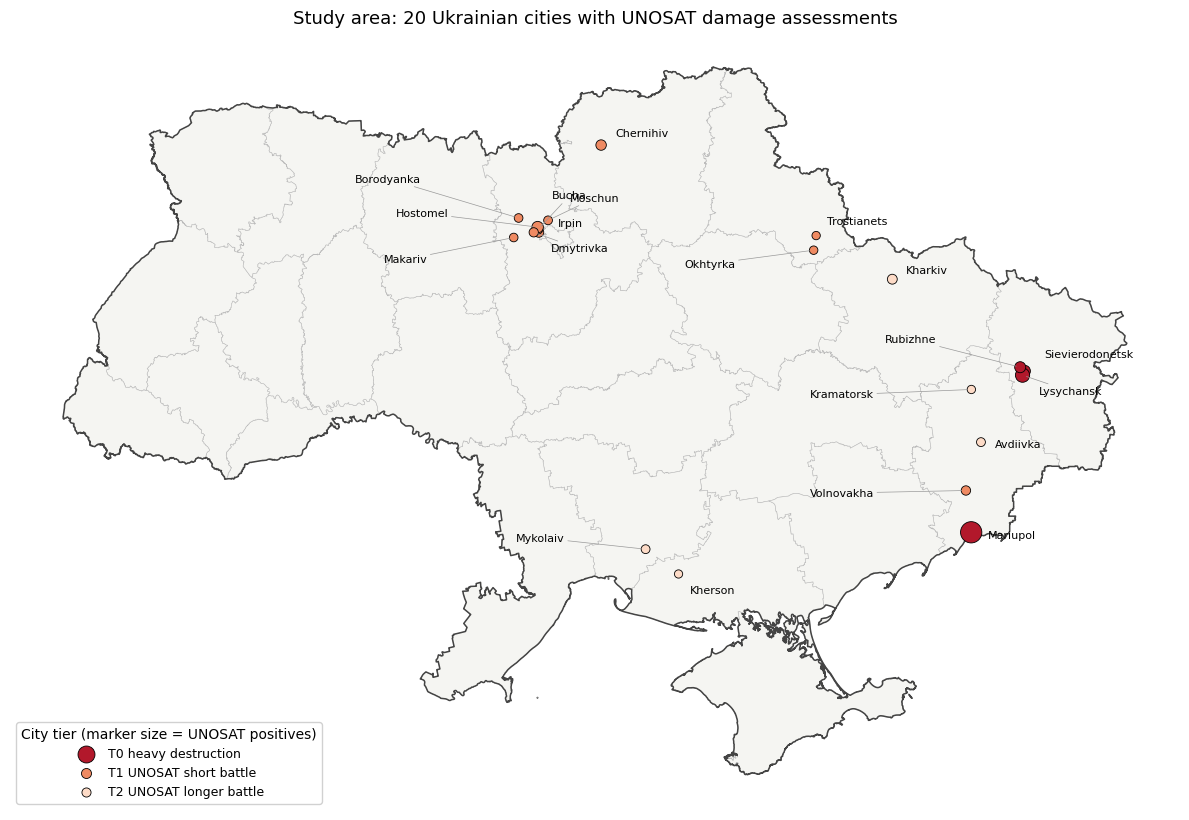

Saved: /content/drive_f/masterthesis/data/outputs/cell_21_study_area_figure/fig_study_area_ukraine.png


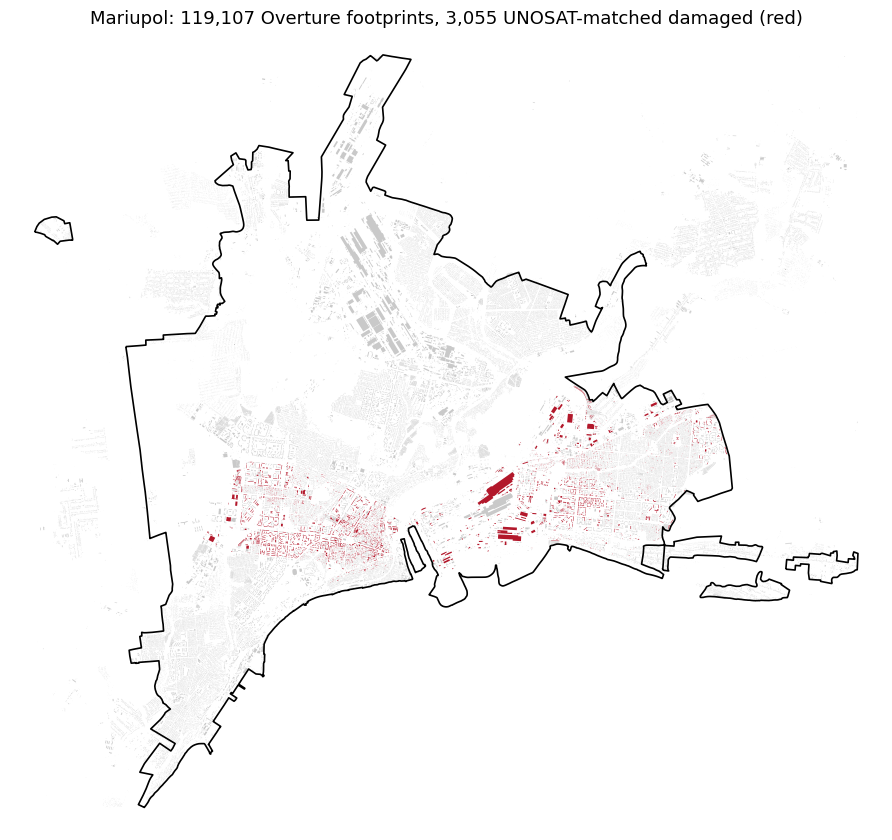

Saved: /content/drive_f/masterthesis/data/outputs/cell_21_study_area_figure/fig_study_area_mariupol.png


In [7]:
# @title CELL 21: STUDY AREA FIGURES (THESIS FIGURES I.1 + I.2)
# =============================================================================
# Fully autonomous. Produces TWO separate figures:
#   fig_study_area_ukraine.png  - Ukraine (COD-AB adm0+adm1) with the 20 study
#                                 cities, tier-colored, size = UNOSAT positives,
#                                 decluttered labels with leader lines
#   fig_study_area_mariupol.png - Mariupol: city boundary + Overture footprints
#                                 (grey) + UNOSAT-matched damaged (red), zoomed
# Requires only Cell 4 (DATA_ROOT, OUTPUTS_DIR, CITIES_DIR, UKR_BOUNDARIES,
# CITIES_CONFIG_FILE).
# =============================================================================
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import json
import glob
import os
import re
from pathlib import Path

CELL_ID = "cell_21_study_area_figure"
fig_path = Path(OUTPUTS_DIR) / CELL_ID
fig_path.mkdir(exist_ok=True)

INSET_CITY = "Mariupol"
TIER_COLORS = {0: "#b2182b", 1: "#ef8a62", 2: "#fddbc7"}
TIER_LABELS = {0: "T0 heavy destruction", 1: "T1 UNOSAT short battle", 2: "T2 UNOSAT longer battle"}

# Manual label offsets (points) for cluster declutter; leader line drawn if far.
LABEL_OFFSETS = {
    "Borodyanka": (-70, 26), "Makariv": (-62, -18), "Hostomel": (-64, 8),
    "Bucha": (10, 22), "Irpin": (14, 4), "Moschun": (16, 14), "Dmytrivka": (12, -14),
    "Rubizhne": (-60, 18), "Sievierodonetsk": (14, 10), "Lysychansk": (12, -14),
    "Kramatorsk": (-70, -6), "Avdiivka": (10, -4), "Volnovakha": (-66, -4),
    "Mariupol": (12, -4), "Kherson": (8, -14), "Mykolaiv": (-58, 6),
    "Kharkiv": (10, 4), "Chernihiv": (10, 6), "Okhtyrka": (-56, -12), "Trostianets": (8, 8),
}

print("=" * 70)
print("CELL 21: STUDY AREA FIGURES")
print("=" * 70)

# ---- 1. Active-tier cities from config ----
with open(CITIES_CONFIG_FILE, "r", encoding="utf-8") as f:
    cities_cfg = json.load(f)
cities_all = cities_cfg.get("cities", cities_cfg)
active = {name: c for name, c in cities_all.items() if c.get("tier") in (0, 1, 2)}
print(f"Active-tier cities: {len(active)}")

# ---- 2. Ukraine boundaries: COD-AB admbnda shapefiles ----
def load_cod_ab_level(root, level):
    files = sorted(glob.glob(os.path.join(str(root), "**", "*.shp"), recursive=True))
    for f in files:
        base = os.path.basename(f).lower()
        if "admbnda" not in base:
            continue
        m = re.search(r"adm(\d)", base)
        if m and int(m.group(1)) == level:
            return gpd.read_file(f).to_crs(4326)
    return None

adm0_gdf = load_cod_ab_level(UKR_BOUNDARIES, 0)
adm1_gdf = load_cod_ab_level(UKR_BOUNDARIES, 1)
print(f"ADM0 loaded: {adm0_gdf is not None} | ADM1 oblasts: {len(adm1_gdf) if adm1_gdf is not None else 0}")

# ---- 3. City geometries from master file ----
city_boundaries_file = Path(DATA_ROOT) / "bda_city_boundaries.geojson"
cities_gdf = gpd.read_file(city_boundaries_file).to_crs(4326)
city_col = "city_name" if "city_name" in cities_gdf.columns else None
if city_col is None:
    for col in cities_gdf.columns:
        if col == "geometry":
            continue
        try:
            vals = set(cities_gdf[col].astype(str).unique())
        except Exception:
            continue
        if len(vals & set(active.keys())) >= min(3, len(active)):
            city_col = col
            break
if city_col is None:
    print("Columns:", list(cities_gdf.columns))
    raise KeyError("No city-name column found")
cities = cities_gdf[cities_gdf[city_col].isin(active.keys())].copy()
cities = cities.drop_duplicates(subset=city_col, keep="last")
cities["tier"] = cities[city_col].map(lambda n: active[n]["tier"])
print(f"City geometries: {len(cities)} of {len(active)} (column '{city_col}')")

# ---- 4. AOI helpers and UNOSAT positives ----
def find_aoi(name):
    for root in (Path(CITIES_DIR) / name, Path(DATA_ROOT) / "cities" / name):
        f = root / "AOI.geojson"
        if f.exists():
            return f
    hits = list(Path(DATA_ROOT).glob(f"**/{name}/AOI.geojson"))
    return hits[0] if hits else None

def split_aoi(aoi):
    poly = aoi[aoi.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
    if "damage_binary" in poly.columns:
        bld = poly[poly["damage_binary"].notna()].copy()
        frame = poly[poly["damage_binary"].isna()].copy()
    else:
        med = poly.geometry.area.median()
        bld = poly[poly.geometry.area <= med * 1000].copy()
        frame = poly[poly.geometry.area > med * 1000].copy()
    return bld, frame

pos_counts = {}
for name in active.keys():
    aoi_file = find_aoi(name)
    if aoi_file is None:
        pos_counts[name] = 0
        print(f"  WARNING: no AOI.geojson found for {name}")
        continue
    bld, _ = split_aoi(gpd.read_file(aoi_file))
    pos_counts[name] = int((bld["damage_binary"] == 1).sum()) if "damage_binary" in bld.columns else 0
cities["positives"] = cities[city_col].map(pos_counts)
print(f"Positives loaded for {sum(v > 0 for v in pos_counts.values())} cities, "
      f"total {sum(pos_counts.values())}")

# ---- 5. FIGURE 1: Ukraine overview ----
fig1, ax1 = plt.subplots(figsize=(12, 8.5))
if adm1_gdf is not None:
    adm1_gdf.plot(ax=ax1, edgecolor="#bbbbbb", facecolor="#f5f5f2", linewidth=0.4)
if adm0_gdf is not None:
    adm0_gdf.boundary.plot(ax=ax1, color="#444444", linewidth=1.1)

for tier in (0, 1, 2):
    sub = cities[cities["tier"] == tier]
    if len(sub) == 0:
        continue
    pts = sub.geometry.representative_point()
    sizes = 35 + 200 * (sub["positives"] / max(1, cities["positives"].max()))
    ax1.scatter(pts.x, pts.y, s=sizes, color=TIER_COLORS[tier], edgecolor="black",
                linewidth=0.6, zorder=5, label=TIER_LABELS[tier])

for _, row in cities.iterrows():
    name = row[city_col]
    pt = row.geometry.representative_point()
    dx, dy = LABEL_OFFSETS.get(name, (8, 4))
    far = (dx * dx + dy * dy) ** 0.5 > 18
    ax1.annotate(name, (pt.x, pt.y), fontsize=8, xytext=(dx, dy),
                 textcoords="offset points", zorder=6,
                 ha="left" if dx >= 0 else "right",
                 arrowprops=dict(arrowstyle="-", color="#999999", lw=0.5,
                                 shrinkA=0, shrinkB=3) if far else None)

ax1.legend(loc="lower left", fontsize=9, title="City tier (marker size = UNOSAT positives)",
           framealpha=0.9)
ax1.set_title(f"Study area: {len(cities)} Ukrainian cities with UNOSAT damage assessments",
              fontsize=13)
ax1.set_axis_off()
plt.tight_layout()
out1 = fig_path / "fig_study_area_ukraine.png"
plt.savefig(out1, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out1}")

# ---- 6. FIGURE 2: Mariupol close-up with city boundary ----
aoi_m = gpd.read_file(find_aoi(INSET_CITY))
bld, frame = split_aoi(aoi_m)

boundary_gdf = None
boundary_file = Path(CITIES_DIR) / INSET_CITY / "boundary.geojson"
if boundary_file.exists():
    boundary_gdf = gpd.read_file(boundary_file).to_crs(bld.crs)
elif len(frame) > 0:
    boundary_gdf = frame.loc[[frame.geometry.area.idxmin()]]

fig2, ax2 = plt.subplots(figsize=(11, 8.5))
if "damage_binary" in bld.columns:
    bld[bld["damage_binary"] != 1].plot(ax=ax2, facecolor="#c9c9c9", edgecolor="none")
    bld[bld["damage_binary"] == 1].plot(ax=ax2, facecolor="#b2182b", edgecolor="none")
    n_pos = int((bld["damage_binary"] == 1).sum())
else:
    bld.plot(ax=ax2, facecolor="#c9c9c9", edgecolor="none")
    n_pos = 0
if boundary_gdf is not None:
    boundary_gdf.boundary.plot(ax=ax2, color="black", linewidth=1.2, zorder=6)

zoom_src = boundary_gdf if boundary_gdf is not None else bld
minx, miny, maxx, maxy = zoom_src.total_bounds
mx = (maxx - minx) * 0.03
my = (maxy - miny) * 0.03
ax2.set_xlim(minx - mx, maxx + mx)
ax2.set_ylim(miny - my, maxy + my)

ax2.set_title(f"{INSET_CITY}: {len(bld):,} Overture footprints, "
              f"{n_pos:,} UNOSAT-matched damaged (red)", fontsize=13)
ax2.set_axis_off()
plt.tight_layout()
out2 = fig_path / "fig_study_area_mariupol.png"
plt.savefig(out2, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out2}")